# EURUSD Exchange Rate Prediction
## Phase 1: Data Preparation & Baseline Setup

**Project:** University Final Project  
**Data Source:** MetaTrader 5 (Daily OHLCV bars) for the notebook's live fetch; the production training in [`_train_pipeline.py`](../_train_pipeline.py) reads the same OHLCV from [`results/eurusd_features.csv`](../results/eurusd_features.csv).  
**Objective:** Forecast the next trading day's EUR/USD move. Two prediction targets are used:
- **Direction** (binary classification) — does the next close finish higher or lower?
- **Return** (regression) — the next day's continuous % return.

The deployed models are **Multi-Task**: a GBM dual pipeline (classifier + regressor) and a single Multi-Task LSTM with two heads predict both targets together.

### Mathematical Formulation
Let the observed closing price at time $t$ be $P_t$, with log return $r_t = \ln(P_t / P_{t-1})$.

Binary direction target:
$$ 
y^{\text{dir}}_t = \begin{cases} 
1 & \text{if } P_{t+1} > P_t \\ 
0 & \text{otherwise} 
\end{cases} 
$$

Continuous return target: $\; y^{\text{ret}}_t = \dfrac{P_{t+1} - P_t}{P_t}$

---

### Two tracks in this notebook
- **Exploratory baseline track (Sections 1–18):** research and teaching — bias-variance diagnosis, learning curves, TimeSeriesSplit CV, multi-model comparison, Optuna tuning, and separate baseline GBM/LSTM models. These train on price-only / technical features **without** the FRED macro feature and **without** PCA, and they are **not** the deployed models.
- **Production track (Section 2B + Section 19):** the real, deployed pipeline — adds the FRED `yield_differential` macro feature, applies PCA to the autoregressive lags, and trains the Multi-Task GBM + LSTM. This is a faithful in-notebook reproduction of [`_train_pipeline.py`](../_train_pipeline.py) and produces exactly the artifacts that [`app.py`](../app.py) / [`api.py`](../api.py) load.

### Notebook Structure
| # | Section | Track | Purpose |
|---|---------|-------|---------|
| 1 | Environment Setup & Dependencies | both | One-time package setup |
| 2 | Connect & Fetch Data | both | MT5 daily OHLCV ingestion with diagnostics |
| 2B | Macro Feature Ingestion (FRED) | production | US10Y − DE10Y bond-yield differential, UTC-aligned, ffilled (no look-ahead) |
| 3 | Basic Feature Engineering | baseline | Log return, SMAs, rolling volatility, bar dynamics, autoregressive lags, day-of-week cyclical encoding, binary target |
| 4 | Advanced Feature Engineering | baseline | ~40 technical indicators (RSI, MACD, Stochastics, ATR, Bollinger, etc.) |
| 5 | Bias-Variance Diagnosis | baseline | Detect underfitting / overfitting |
| 6 | Learning Curves | baseline | Visual bias-variance signal |
| 7 | TimeSeriesSplit CV | baseline | Correct temporal cross-validation |
| 8 | Multi-Model Training | baseline | RF, GBM, XGBoost, LightGBM comparison |
| 9 | Hyperparameter Tuning | baseline | Optuna Bayesian search |
| 10 | Final Hold-Out Evaluation | baseline | Clean out-of-sample test |
| 11 | Residual Analysis | baseline | Diagnostic plots |
| 12 | Comparison Table & Export | baseline | `results/comparison_table.csv` |
| 13 | EDA & Regression Features | baseline | ADF stationarity, ACF/PACF, continuous-return target, `results/eurusd_features.csv` |
| 14 | LSTM Sequence Modeling (regression) | baseline | Single-output LSTM predicting next-day return |
| 15 | Gradient Boosting (classification) | baseline | GBM direction classifier + GridSearch tuning |
| 16 | LSTM Classification (sliding windows) | baseline | Sequence LSTM predicting direction |
| 17 | Final Model Selection & Persistence | baseline | Saves the exploratory baseline GBM (NOT the production model) |
| 18 | Model Card | both | Strengths, limitations, future work |
| 19 | **Production Multi-Task Pipeline** | **production** | **FRED + PCA + GBM dual pipeline + Multi-Task LSTM — regenerates the deployed artifacts** |


## Section 1: Environment Setup & Dependencies
In this section, we import all the foundational libraries required for data ingestion, manipulation, and visualization. We also set a global random seed to ensure reproducible results across our experiments. Run this cell **once** before all others.

In [ ]:
import subprocess, sys

# Install all packages required across every phase of this notebook.
# --quiet suppresses verbose pip output; only errors will be shown.
packages = [
    "MetaTrader5", "pandas", "numpy", "matplotlib",
    "scikit-learn", "xgboost", "lightgbm", "optuna", "statsmodels", "tensorflow"
]

for pkg in packages:
    subprocess.check_call([sys.executable, "-m", "pip", "install", pkg, "--quiet"])

print("✅ All dependencies installed successfully.")
print(f"Python: {sys.version}")

✅ All dependencies installed successfully.
Python: 3.12.5 | packaged by conda-forge | (main, Aug  8 2024, 18:24:51) [MSC v.1940 64 bit (AMD64)]


## Section 2 — Connect & Fetch EURUSD Data from MT5
**Prerequisite:** MetaTrader5 desktop must be open and logged in before running these cells.

In [ ]:
import MetaTrader5 as mt5
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import warnings
import os

warnings.filterwarnings('ignore')
os.makedirs("../results", exist_ok=True)  # ensure results/ exists
os.makedirs("../models", exist_ok=True)   # ensure models/ exists

# Global configuration for reproducibility
RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

# ── MT5 Configuration ──────────────────────────────────────────────────
SYMBOL    = "EURUSD"   # change to "EURUSD.m" or "EURUSD.pro" if needed
TIMEFRAME = mt5.TIMEFRAME_D1

print("=" * 40)
print("Environment setup complete.")
print(f"Symbol   : {SYMBOL}")
print(f"Timeframe: D1 (Daily)")
print(f"Seed     : {RANDOM_STATE}")
print("=" * 40)

Environment setup complete.
Symbol   : EURUSD
Timeframe: D1 (Daily)
Seed     : 42


In [ ]:
def connect_and_fetch(symbol: str, timeframe, max_bars: int = 200_000) -> pd.DataFrame | None:
    """
    Fetch OHLCV history from MetaTrader5.

    Uses date-based copy_rates_from as the primary method (more reliable
    across brokers) and falls back to position-based copy_rates_from_pos
    if the first attempt returns no data.

    Parameters
    ----------
    symbol    : MT5 symbol name (e.g. "EURUSD")
    timeframe : MT5 timeframe constant (e.g. mt5.TIMEFRAME_M15)
    max_bars  : Maximum bars to request

    Returns
    -------
    DataFrame with columns [open, high, low, close, tick_volume] indexed by datetime,
    sorted ascending. Returns None on failure.
    """
    from datetime import datetime, timezone
    import time as _time

    print("Initializing MT5...")
    if not mt5.initialize():
        print(f"  ✗ MT5 init failed: {mt5.last_error()}")
        print("  → Ensure MetaTrader5 is open and you are logged in.")
        return None

    # Make sure the symbol is available and visible in Market Watch
    info = mt5.symbol_info(symbol)
    if info is None:
        available = [s.name for s in mt5.symbols_get() if "EUR" in s.name and "USD" in s.name]
        print(f"  ✗ Symbol '{symbol}' not found. Available EUR/USD: {available[:8]}")
        mt5.shutdown()
        return None

    if not info.visible:
        mt5.symbol_select(symbol, True)
        _time.sleep(1)

    # Primary: date-based fetch backwards from now
    utc_now = datetime.now(timezone.utc)
    rates   = mt5.copy_rates_from(symbol, timeframe, utc_now, max_bars)

    # Fallback: position-based
    if rates is None or len(rates) == 0:
        print("  ↪ Date-based fetch empty, trying position-based fallback...")
        rates = mt5.copy_rates_from_pos(symbol, timeframe, 0, max_bars)

    err = mt5.last_error()
    mt5.shutdown()

    if rates is None or len(rates) == 0:
        print(f"  ✗ No data returned. MT5 error: {err}")
        print("  Tips: open a EURUSD D1 chart in MT5, then retry.")
        return None

    df = pd.DataFrame(rates)
    df['time'] = pd.to_datetime(df['time'], unit='s')
    df.set_index('time', inplace=True)
    df.sort_index(inplace=True)

    print(f"  ✓ Fetched {len(df):,} bars  "
          f"({df.index[0].date()} → {df.index[-1].date()})")
    return df[['open', 'high', 'low', 'close', 'tick_volume']]


# Auto-detect available bars before the full fetch
mt5.initialize()
_probe     = mt5.copy_rates_from_pos(SYMBOL, TIMEFRAME, 0, 20_000)
TOTAL_BARS = len(_probe) if _probe is not None else 10_000
mt5.shutdown()

print(f"Available Daily bars: {TOTAL_BARS:,}")
print(f"Fetching {TOTAL_BARS:,} bars for {SYMBOL}...")
raw_df = connect_and_fetch(SYMBOL, TIMEFRAME, max_bars=TOTAL_BARS)

Available Daily bars: 15,722
Fetching 15,722 bars for EURUSD...
Initializing MT5...
  ✓ Fetched 15,722 bars  (1971-01-03 → 2026-06-19)


In [ ]:
# MT5 Connectivity Diagnostic — run if the fetch above fails
print("=" * 55)
print("MT5 DIAGNOSTIC REPORT")
print("=" * 55)

if not mt5.initialize():
    print(f"FAILED: {mt5.last_error()} — open MT5 and log in first.")
else:
    term = mt5.terminal_info()
    acc  = mt5.account_info()
    print(f"Connected  : {term.connected}")
    print(f"Terminal   : {term.path}")
    if acc:
        print(f"Account    : {acc.login}  |  Server: {acc.server}")
    else:
        print("Account    : NOT LOGGED IN")

    info = mt5.symbol_info(SYMBOL)
    if info:
        rates = mt5.copy_rates_from_pos(SYMBOL, TIMEFRAME, 0, 3)
        if rates is not None and len(rates):
            print(f"Symbol     : {info.name}  (spread={info.spread})")
            print(f"Latest bar : {pd.to_datetime(rates[-1]['time'], unit='s')}  "
                  f"close={rates[-1]['close']:.5f}")
        else:
            print(f"Test fetch FAILED: {mt5.last_error()}")
    else:
        eur = [s.name for s in mt5.symbols_get() if "EUR" in s.name and "USD" in s.name]
        print(f"Symbol '{SYMBOL}' NOT FOUND.  Try: {eur[:6]}")

    mt5.shutdown()
print("=" * 55)

MT5 DIAGNOSTIC REPORT
Connected  : True
Terminal   : C:\Program Files\ActivTrades EU MetaTrader 5
Account    : 878329  |  Server: ActivTradesEU-Server
Symbol     : EURUSD  (spread=103)
Latest bar : 2026-06-19 00:00:00  close=1.14647


## Section 2B — Macro Feature Ingestion (FRED Bond-Yield Differential)

Price action alone is endogenous — it carries no information about the **macro forces** that actually drive EUR/USD. The single most important of those is the **interest-rate differential** between the US and the Eurozone: when US 10-year yields rise relative to German 10-year yields, capital flows toward the dollar and EUR/USD tends to fall (and vice versa).

We therefore add one **exogenous** feature pulled from the Federal Reserve's [FRED](https://fred.stlouisfed.org/) database:

$$ \text{yield\_differential}_t = \text{US10Y}_t - \text{DE10Y}_t $$

| Series | FRED code | Frequency |
|--------|-----------|-----------|
| US 10-Year Treasury | `DGS10` | Daily |
| German 10-Year Govt | `IRLTLT01DEM156N` | Monthly (forward-filled onto the daily index) |

**Why this matters for *your* question — "is the model trained with FRED data?"**
Yes. This `yield_differential` column becomes one of the **24 features** in `src/features.py` `FEATURE_COLUMNS`, and both production models ([`best_gbm_eurusd.pkl`](../models/best_gbm_eurusd.pkl) and [`lstm_multitask_eurusd.keras`](../models/lstm_multitask_eurusd.keras)) are trained on it. The cell below performs exactly the same FRED fetch + merge that `_train_pipeline.py` and the live inference service use.

**No look-ahead bias:** the merge uses a left-join + forward-fill (`merge_macro_features`), which only ever carries a *past* yield value forward — never a future one backward.

> ⚠️ **Coverage caveat:** `fetch_yield_differential` falls back to a cached snapshot ([`results/yield_differential.csv`](../results/yield_differential.csv)) when FRED is unreachable. That cache may only cover a recent window, in which case older OHLCV bars get `NaN` and are dropped downstream — shrinking the training set. For full-history training, make sure FRED is reachable (or set `FRED_API_KEY` in `.env`). The cell prints a coverage diagnostic so you can see exactly how much of the history actually received macro data.


In [ ]:
# Section 2B — Macro Feature Ingestion (FRED: US 10Y − DE 10Y bond-yield differential)
#
# This is the macro feature the PRODUCTION models are trained on. It reuses the
# exact same code paths as _train_pipeline.py (Section 1B) and src/inference.py,
# so the notebook's feature matrix stays byte-for-byte aligned with what
# app.py / api.py serve at inference time. The fallback chain inside
# fetch_yield_differential is: official FRED API (needs FRED_API_KEY) →
# FRED public CSV endpoint (no key) → last cached snapshot on disk.
import sys, os, json

sys.path.insert(0, os.path.abspath('..'))  # make the top-level src/ package importable from notebooks/
from src.macro_data import fetch_yield_differential
from src.features import merge_macro_features

with open('../config.json') as f:
    CONFIG = json.load(f)
macro_cfg = CONFIG.get('macro', {})

assert raw_df is not None, "raw_df is None — run Section 2 first."

macro_df, macro_source = fetch_yield_differential(
    raw_df.index.min(), raw_df.index.max(),
    series_ids=macro_cfg.get('fred_series'),
    cache_path=os.path.join('..', macro_cfg.get('cache_path', 'results/yield_differential.csv')),
)

if macro_df is not None:
    raw_df = merge_macro_features(raw_df, macro_df)
    print(f"✓ Merged FRED yield_differential via '{macro_source}': "
          f"{len(macro_df):,} macro observations "
          f"({macro_df.index[0].date()} → {macro_df.index[-1].date()})")
    # Coverage diagnostic: ffill only carries values FORWARD, so any OHLCV bars
    # older than the first macro observation stay NaN and get dropped during
    # feature engineering. With only the cached snapshot reachable this can
    # shrink the usable history dramatically — see the markdown note above.
    n_covered = raw_df['yield_differential'].notna().sum()
    print(f"  yield_differential populated on {n_covered:,}/{len(raw_df):,} bars "
          f"({n_covered / len(raw_df):.1%} of history).")
else:
    raw_df = raw_df.assign(yield_differential=0.0)
    macro_source = "unavailable"
    print("⚠ No live or cached FRED data reachable — yield_differential defaulted to 0.0")

print(f"\nraw_df now carries columns: {list(raw_df.columns)}")
display(raw_df[['close', 'yield_differential']].tail(3))


## Section 2C — FRED Macro Feature: Table, Chart & Ablation Test

Section 2B *fetched* the FRED data; this section *shows* it and *tests* it. Three parts:

1. **Table** — the raw FRED series (`US10Y`, `DE10Y`) and the derived `yield_differential = US10Y − DE10Y`, plus summary statistics. Exported to `results/2C_fred_table.csv`.
2. **Charts** — (a) the two raw bond-yield series, (b) the derived differential over time, and (c) `yield_differential` overlaid on EUR/USD close (dual axis) to visualise the macro relationship.
3. **Ablation test** — the key result you asked for: train the *same* GBM direction classifier **with** vs **without** the FRED feature and compare Accuracy / ROC-AUC, then show where `yield_differential` ranks in the model's feature importance.

> These cells are **self-contained** — they read OHLCV from `results/eurusd_features.csv` and pull FRED directly, so they run even without a live MT5 terminal and regardless of whether Sections 2/2B were executed.


In [ ]:
import os, sys, json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

sys.path.insert(0, os.path.abspath('..'))  # make the repo-root `src` package importable
from src.macro_data import fetch_yield_differential
from src.features import merge_macro_features

In [ ]:
# Section 2C (2/3) — Charts: how the FRED feature is derived & how it tracks EUR/USD
fig, axes = plt.subplots(2, 1, figsize=(14, 8), sharex=True)

# (1) Raw components US10Y vs DE10Y (the two series the differential is built from)
if components is not None:
    axes[0].plot(components.index, components['US10Y'], label='US 10Y (DGS10)', color='navy', lw=1)
    axes[0].plot(components.index, components['DE10Y'], label='DE 10Y (IRLTLT01DEM156N)', color='darkorange', lw=1)
    axes[0].set_title('Raw FRED series — US vs German 10Y Government Bond Yields')
    axes[0].set_ylabel('Yield (%)')
    axes[0].legend(loc='best')
    axes[0].grid(True, alpha=0.3)
else:
    axes[0].text(0.5, 0.5, 'Raw component series unavailable — showing differential only',
                 ha='center', va='center', transform=axes[0].transAxes)

# (2) The DERIVED feature: yield_differential = US10Y − DE10Y
diff_series = (components['yield_differential'] if components is not None
               else fred_table['yield_differential'])
axes[1].plot(diff_series.index, diff_series.values, color='crimson', lw=1)
axes[1].axhline(0, color='grey', ls='--', lw=0.8)
axes[1].fill_between(diff_series.index, diff_series.values, 0,
                     where=(diff_series.values >= 0), color='crimson', alpha=0.10)
axes[1].set_title('Derived model feature:  yield_differential = US10Y − DE10Y')
axes[1].set_ylabel('Differential (percentage points)')
axes[1].set_xlabel('Date')
axes[1].grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('../results/2C_fred_yield_differential.png', dpi=120, bbox_inches='tight')
plt.show()

# (3) Macro relationship: yield_differential vs EUR/USD close (dual axis, overlapping window)
diff_naive = diff_series.copy()
if getattr(diff_naive.index, 'tz', None) is not None:
    diff_naive.index = diff_naive.index.tz_convert(None)
aligned = pd.DataFrame({'close': ohlcv['close']}).join(diff_naive.rename('yld'), how='inner').dropna()

fig, ax1 = plt.subplots(figsize=(14, 4))
ax1.plot(aligned.index, aligned['close'], color='steelblue', lw=1, label='EUR/USD close')
ax1.set_ylabel('EUR/USD close', color='steelblue')
ax1.tick_params(axis='y', labelcolor='steelblue')
ax2 = ax1.twinx()
ax2.plot(aligned.index, aligned['yld'], color='crimson', lw=1, label='yield_differential')
ax2.set_ylabel('US10Y − DE10Y (pp)', color='crimson')
ax2.tick_params(axis='y', labelcolor='crimson')
corr = aligned['close'].corr(aligned['yld'])
ax1.set_title(f'EUR/USD close vs US−DE yield differential  '
              f'(overlap {aligned.index.min().date()} → {aligned.index.max().date()},  '
              f'level corr = {corr:+.2f})')
ax1.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('../results/2C_fred_vs_eurusd.png', dpi=120, bbox_inches='tight')
plt.show()
print(f"Level correlation (EUR/USD close vs yield_differential) over the overlap: {corr:+.3f}")
print("Saved → results/2C_fred_yield_differential.png, results/2C_fred_vs_eurusd.png")


In [ ]:
# Section 2C (3/3) — Ablation TEST: does the FRED feature actually help the model?
#
# Train the SAME GBM direction classifier twice on a chronological hold-out —
# once WITH yield_differential among the inputs, once WITHOUT — and compare.
# This is the concrete "test with FRED" result.
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.metrics import accuracy_score, roc_auc_score

from src.features import (
    add_advanced_features, FEATURE_COLUMNS, LAG_COLUMNS,
    TARGET_DIRECTION_COLUMN, fit_lag_pca, apply_lag_pca, model_input_columns,
)

# Merge FRED into OHLCV, engineer the canonical features, PCA-reduce the lags
merged = merge_macro_features(ohlcv.copy(), macro_df)
feat = add_advanced_features(merged)
print(f"Engineered rows after FRED merge + SMA_200/lag warm-up: {len(feat):,}")

split = int(len(feat) * CONFIG['split']['gbm_train_fraction'])
lag_scaler, lag_pca = fit_lag_pca(
    feat.iloc[:split], lag_columns=LAG_COLUMNS,
    variance_threshold=CONFIG['pca']['variance_threshold'],
)
red = apply_lag_pca(feat, lag_scaler, lag_pca, lag_columns=LAG_COLUMNS)

cols_with = model_input_columns(lag_pca, base_columns=FEATURE_COLUMNS, lag_columns=LAG_COLUMNS)
cols_without = [c for c in cols_with if c != 'yield_differential']

y = red[TARGET_DIRECTION_COLUMN]
y_tr, y_te = y.iloc[:split], y.iloc[split:]


def quick_gbm(cols):
    """One fast GBM fit (no grid search) on a chronological 80/20 split."""
    X_tr, X_te = red[cols].iloc[:split], red[cols].iloc[split:]
    sc = StandardScaler().fit(X_tr)
    model = GradientBoostingClassifier(
        n_estimators=200, max_depth=3, learning_rate=0.05,
        random_state=CONFIG['random_state'],
    )
    model.fit(sc.transform(X_tr), y_tr)
    prob = model.predict_proba(sc.transform(X_te))[:, 1]
    return accuracy_score(y_te, (prob >= 0.5).astype(int)), roc_auc_score(y_te, prob), model


acc_wo, auc_wo, _ = quick_gbm(cols_without)
acc_w, auc_w, model_with = quick_gbm(cols_with)

ablation = pd.DataFrame(
    {
        'Accuracy': [acc_wo, acc_w, acc_w - acc_wo],
        'ROC-AUC': [auc_wo, auc_w, auc_w - auc_wo],
    },
    index=['WITHOUT yield_differential', 'WITH yield_differential', 'Δ  (FRED effect)'],
).round(4)
print("\n=== Ablation test — GBM direction classifier (chronological hold-out) ===")
display(ablation)
ablation.to_csv('../results/2C_fred_ablation.csv')

# Where does the FRED feature rank by Gini importance inside the full model?
imp = pd.Series(model_with.feature_importances_, index=cols_with).sort_values(ascending=False)
rank = list(imp.index).index('yield_differential') + 1
print(f"\nyield_differential — Gini importance {imp['yield_differential']:.4f}  "
      f"(rank {rank} of {len(cols_with)} features)")

fig, ax = plt.subplots(figsize=(10, 6))
colors = ['crimson' if c == 'yield_differential' else 'steelblue' for c in imp.index]
ax.barh(imp.index[::-1], imp.values[::-1], color=colors[::-1])
ax.set_title('GBM Feature Importance — FRED yield_differential highlighted (crimson)')
ax.set_xlabel('Gini importance')
ax.grid(True, axis='x', alpha=0.3)
plt.tight_layout()
plt.savefig('../results/2C_fred_feature_importance.png', dpi=120, bbox_inches='tight')
plt.show()
print("Saved → results/2C_fred_ablation.csv, results/2C_fred_feature_importance.png")


## Section 3 — Advanced Feature Engineering
To effectively capture the temporal dependencies and non-linearities in the EURUSD time series, we expand our feature space beyond simple rolling averages. 

According to time-series best practices, we engineer the following features:
1. **Autoregressive Lags**: By shifting the log returns ($log(P_t / P_{t-1})$), we create lagged features ($lag_1, lag_2, ...$) that allow the model to learn from short-term historical autocorrelation.
2. **Intraday Volatility (Bar Dynamics)**: We quantify the intra-bar noise using the normalized range $\frac{High_t - Low_t}{Open_t}$.
3. **Cyclical Time Encoding**: Time variables like 'day of the week' are periodic. To preserve this seasonality mathematically without introducing ordinal magnitude errors, we apply sine and cosine transformations:
   $$X_{sin} = \sin\left(\frac{2\pi \cdot day}{7}\right), \quad X_{cos} = \cos\left(\frac{2\pi \cdot day}{7}\right)$$

Shape   : 15,523 rows × 21 cols
Range   : 1971-10-26 00:00:00  →  2026-06-19 00:00:00

Target distribution:
target
Down (0)    0.509
Up (1)      0.491
Name: proportion, dtype: float64


,close,log_return,bar_dynamics,day_sin,target
time,,,,,
2026-06-15,1.15881,-0.001423,0.003319,0.000000,1
2026-06-16,1.16082,0.001733,0.003891,0.781831,0
2026-06-17,1.15032,-0.009086,0.011983,0.974928,0
2026-06-18,1.14612,-0.003658,0.006782,0.433884,1
2026-06-19,1.14647,0.000305,0.005506,-0.433884,0


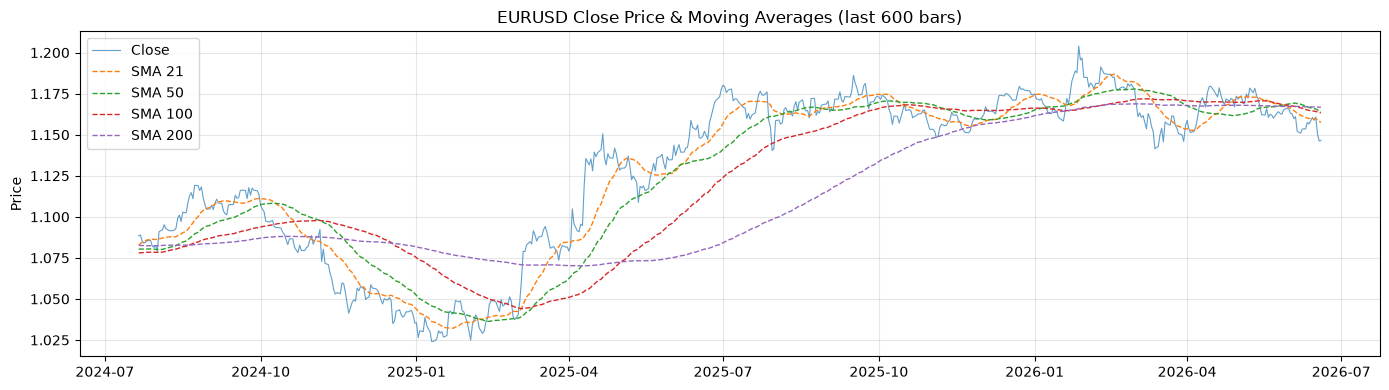

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

def add_advanced_features(df: pd.DataFrame) -> pd.DataFrame:
    """
    Add advanced time-series features combining trend, autoregression, 
    intraday dynamics, and cyclical seasonality.
    """
    data = df.copy()

    # 1. Log return (Stationarity)
    data['log_return'] = np.log(data['close'] / data['close'].shift(1))

    # 2. Simple Moving Averages (Trend Preservation)
    for period in [21, 50, 100, 200]:
        data[f'SMA_{period}'] = data['close'].rolling(period).mean()

    # 3. Rolling Realised Volatility
    data['volatility_20'] = data['log_return'].rolling(20).std()

    # 4. Bar Dynamics (Intraday volatility)
    data['bar_dynamics'] = (data['high'] - data['low']) / data['open']

    # 5. Autoregressive Lags (Time-series history)
    for lag in range(1, 4):
        data[f'return_lag_{lag}'] = data['log_return'].shift(lag)
        data[f'dynamics_lag_{lag}'] = data['bar_dynamics'].shift(lag)

    # 6. Cyclical Encoding for Day of Week (Seasonality)
    # Monday=0, Sunday=6
    day_of_week = data.index.dayofweek
    data['day_sin'] = np.sin(2 * np.pi * day_of_week / 7)
    data['day_cos'] = np.cos(2 * np.pi * day_of_week / 7)

    # 7. Binary target: 1 if next bar closes HIGHER than current, else 0
    # shift(-1) causes the last row to become NaN.
    data['target'] = (data['close'].shift(-1) > data['close']).astype(int)

    # Clean up any rows with NaN values created by shifts and rolling windows
    data.dropna(inplace=True)
    return data

assert raw_df is not None, "raw_df is None — re-run Section 2 first."
basic_advanced_df = add_advanced_features(raw_df)

print(f"Shape   : {basic_advanced_df.shape[0]:,} rows × {basic_advanced_df.shape[1]} cols")
print(f"Range   : {basic_advanced_df.index[0]}  →  {basic_advanced_df.index[-1]}")
print(f"\nTarget distribution:")
print(basic_advanced_df['target'].value_counts(normalize=True).rename({0: 'Down (0)', 1: 'Up (1)'}).round(3))
display(basic_advanced_df[['close', 'log_return', 'bar_dynamics', 'day_sin', 'target']].tail(5))

# Plotting the Close Price and SMAs
fig, ax = plt.subplots(figsize=(14, 4))
sample = basic_advanced_df.tail(600)  
ax.plot(sample.index, sample['close'],  label='Close',  alpha=0.7, linewidth=0.8)
ax.plot(sample.index, sample['SMA_21'],  label='SMA 21',  linestyle='--', linewidth=1)
ax.plot(sample.index, sample['SMA_50'],  label='SMA 50',  linestyle='--', linewidth=1)
ax.plot(sample.index, sample['SMA_100'], label='SMA 100', linestyle='--', linewidth=1)
ax.plot(sample.index, sample['SMA_200'], label='SMA 200', linestyle='--', linewidth=1)
ax.set_title('EURUSD Close Price & Moving Averages (last 600 bars)')
ax.set_ylabel('Price')
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('../results/01_price_sma_advanced.png', dpi=120, bbox_inches='tight')
plt.show()

## Section 4 — Advanced Feature Engineering
Build 20+ technical indicators. All computed from past data only — zero look-ahead bias.

In [ ]:
def build_advanced_features(df_raw: pd.DataFrame) -> pd.DataFrame:
    """
    Build a rich feature set from raw OHLCV data (no look-ahead bias).
    """
    df = df_raw[['open', 'high', 'low', 'close', 'tick_volume']].copy()
    close = df['close']
    high = df['high']
    low = df['low']

    # ── Trend ─────────────────────────────────────────────────────────
    df['log_return'] = np.log(close / close.shift(1))

    # Simple Moving Averages: 21, 50, 100, 200 periods
    df['SMA_21'] = close.rolling(21).mean()
    df['SMA_50'] = close.rolling(50).mean()
    df['SMA_100'] = close.rolling(100).mean()
    df['SMA_200'] = close.rolling(200).mean()

    # Distance from SMA (normalized)
    df['dist_SMA_21'] = (close - df['SMA_21']) / df['SMA_21']
    df['dist_SMA_50'] = (close - df['SMA_50']) / df['SMA_50']
    df['dist_SMA_100'] = (close - df['SMA_100']) / df['SMA_100']
    df['dist_SMA_200'] = (close - df['SMA_200']) / df['SMA_200']

    # ── Volatility ────────────────────────────────────────────────────
    df['volatility_5'] = df['log_return'].rolling(5).std()
    df['volatility_20'] = df['log_return'].rolling(20).std()

    tr = pd.concat([
        high - low,
        (high - close.shift(1)).abs(),
        (low - close.shift(1)).abs()
    ], axis=1).max(axis=1)
    df['ATR_14'] = tr.ewm(com=13, adjust=False).mean()

    bb_mid = close.rolling(20).mean()
    bb_std = close.rolling(20).std()
    bb_up = bb_mid + 2 * bb_std
    bb_lo = bb_mid - 2 * bb_std
    df['BB_pct_b'] = (close - bb_lo) / (bb_up - bb_lo)
    df['BB_bandwidth'] = (bb_up - bb_lo) / bb_mid

    # ── Oscillators ───────────────────────────────────────────────────
    delta = close.diff()
    avg_gain = delta.clip(lower=0).ewm(com=13, adjust=False).mean()
    avg_loss = (-delta).clip(lower=0).ewm(com=13, adjust=False).mean()
    df['RSI_14'] = 100 - (100 / (1 + avg_gain / avg_loss.replace(0, np.nan)))

    ema12 = close.ewm(span=12, adjust=False).mean()
    ema26 = close.ewm(span=26, adjust=False).mean()
    df['MACD'] = ema12 - ema26
    df['MACD_signal'] = df['MACD'].ewm(span=9, adjust=False).mean()
    df['MACD_hist'] = df['MACD'] - df['MACD_signal']

    low14 = low.rolling(14).min()
    high14 = high.rolling(14).max()
    df['Stoch_K'] = 100 * (close - low14) / (high14 - low14)
    df['Stoch_D'] = df['Stoch_K'].rolling(3).mean()
    df['Williams_R'] = -100 * (high14 - close) / (high14 - low14)
    df['ROC_10'] = close.pct_change(10) * 100

    # ── Memory ────────────────────────────────────────────────────────
    for lag in range(1, 6):
        df[f'lag_{lag}'] = df['log_return'].shift(lag)

    # ── Rolling stats ─────────────────────────────────────────────────
    df['return_mean_5'] = df['log_return'].rolling(5).mean()
    df['return_std_5'] = df['log_return'].rolling(5).std()
    df['return_mean_10'] = df['log_return'].rolling(10).mean()
    df['return_std_10'] = df['log_return'].rolling(10).std()

    # ── Calendar ──────────────────────────────────────────────────────
    df['hour_of_day'] = df.index.hour
    df['day_of_week'] = df.index.dayofweek

    # ── Target ────────────────────────────────────────────────────────
    df['target'] = (close.shift(-1) > close).astype(int)

    df.dropna(inplace=True)
    return df


advanced_df     = build_advanced_features(raw_df)
FEATURE_COLS    = [c for c in advanced_df.columns if c != 'target']

print(f"Advanced dataset : {advanced_df.shape[0]:,} rows × {advanced_df.shape[1]} cols")
print(f"Feature count    : {len(FEATURE_COLS)}")
print(f"Target balance   : {advanced_df['target'].value_counts(normalize=True).round(3).to_dict()}")
display(advanced_df[FEATURE_COLS[:8]].tail(3))

Advanced dataset : 15,523 rows × 39 cols
Feature count    : 38
Target balance   : {0: 0.509, 1: 0.491}


,open,high,low,close,tick_volume,log_return,SMA_21,SMA_50
time,,,,,,,,
2026-06-17,1.16083,1.16164,1.14773,1.15032,162639,-0.009086,1.159077,1.165062
2026-06-18,1.15015,1.15280,1.14500,1.14612,196791,-0.003658,1.158226,1.164504
2026-06-19,1.14604,1.14803,1.14172,1.14647,115501,0.000305,1.157447,1.164018


## Section 5 — Bias-Variance Diagnosis
Measure the train/validation gap on a baseline model before any tuning.

In [ ]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import log_loss

X_all = advanced_df[FEATURE_COLS].values
y_all = advanced_df['target'].values

# Temporal 70/30 split (Rule #1: NO shuffle on time-series)
split = int(len(X_all) * 0.70)
X_tr, X_va = X_all[:split], X_all[split:]
y_tr, y_va = y_all[:split], y_all[split:]

# Scale: fit ONLY on train (Rule #2: prevent data leakage)
scaler = StandardScaler()
X_tr_s = scaler.fit_transform(X_tr)
X_va_s = scaler.transform(X_va)

# Baseline model — untuned Random Forest
baseline = RandomForestClassifier(
    n_estimators=100, max_depth=6, min_samples_leaf=20,
    class_weight='balanced', random_state=RANDOM_STATE, n_jobs=-1
)
baseline.fit(X_tr_s, y_tr)

train_acc = baseline.score(X_tr_s, y_tr)
val_acc   = baseline.score(X_va_s, y_va)
gap       = val_acc - train_acc   # negative = overfitting

print("=" * 45)
print("  BIAS-VARIANCE DIAGNOSIS")
print("=" * 45)
print(f"  Train Accuracy : {train_acc:.4f}")
print(f"  Val   Accuracy : {val_acc:.4f}")
print(f"  Gap            : {gap:+.4f}")
print()
if train_acc < 0.55:
    print("  → HIGH BIAS (Underfitting)")
    print("    Fix: add features, reduce regularization, more complex model")
elif gap < -0.03:
    print("  → HIGH VARIANCE (Overfitting)")
    print("    Fix: increase regularization, reduce max_depth, gather more data")
else:
    print("  → BALANCED — proceed to hyperparameter search")
print("=" * 45)

  BIAS-VARIANCE DIAGNOSIS
  Train Accuracy : 0.6269
  Val   Accuracy : 0.5035
  Gap            : -0.1234

  → HIGH VARIANCE (Overfitting)
    Fix: increase regularization, reduce max_depth, gather more data


## Section 6 — Learning Curves
Plot training vs validation accuracy as a function of training-set size to visually confirm the bias-variance regime.

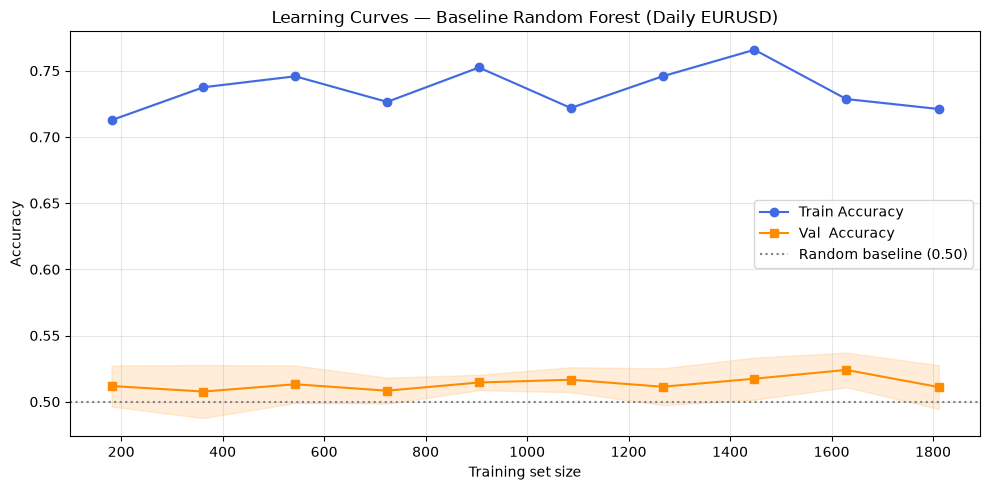

Saved → ../results/02_learning_curves.png


In [ ]:
from sklearn.model_selection import learning_curve, TimeSeriesSplit
from sklearn.ensemble import RandomForestClassifier
import numpy as np

# Use TimeSeriesSplit to keep temporal ordering intact
tscv = TimeSeriesSplit(n_splits=5)

train_sizes, train_scores, val_scores = learning_curve(
    estimator   = RandomForestClassifier(n_estimators=100, max_depth=6,
                                         min_samples_leaf=20,
                                         class_weight='balanced',
                                         random_state=RANDOM_STATE, n_jobs=-1),
    X           = X_tr_s,    # use ONLY the training portion
    y           = y_tr,
    cv          = tscv,
    scoring     = 'accuracy',
    train_sizes = np.linspace(0.1, 1.0, 10),
    n_jobs      = -1
)

train_mean = train_scores.mean(axis=1)
train_std  = train_scores.std(axis=1)
val_mean   = val_scores.mean(axis=1)
val_std    = val_scores.std(axis=1)

fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(train_sizes, train_mean, 'o-', color='royalblue',  label='Train Accuracy')
ax.plot(train_sizes, val_mean,   's-', color='darkorange', label='Val  Accuracy')
ax.fill_between(train_sizes, train_mean - train_std, train_mean + train_std,
                alpha=0.15, color='royalblue')
ax.fill_between(train_sizes, val_mean - val_std,   val_mean + val_std,
                alpha=0.15, color='darkorange')
ax.axhline(y=0.5, linestyle=':', color='grey', label='Random baseline (0.50)')
ax.set_xlabel('Training set size'); ax.set_ylabel('Accuracy')
ax.set_title('Learning Curves — Baseline Random Forest (Daily EURUSD)')
ax.legend(); ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('../results/02_learning_curves.png', dpi=120, bbox_inches='tight')
plt.show()
print("Saved → ../results/02_learning_curves.png")

## Section 7 — TimeSeriesSplit Cross-Validation
Visualise fold boundaries and explain why standard K-Fold causes look-ahead bias on time-series data.

Fold 1: train=1,811 bars | val=1,811 bars
Fold 2: train=3,622 bars | val=1,811 bars
Fold 3: train=5,433 bars | val=1,811 bars
Fold 4: train=7,244 bars | val=1,811 bars
Fold 5: train=9,055 bars | val=1,811 bars


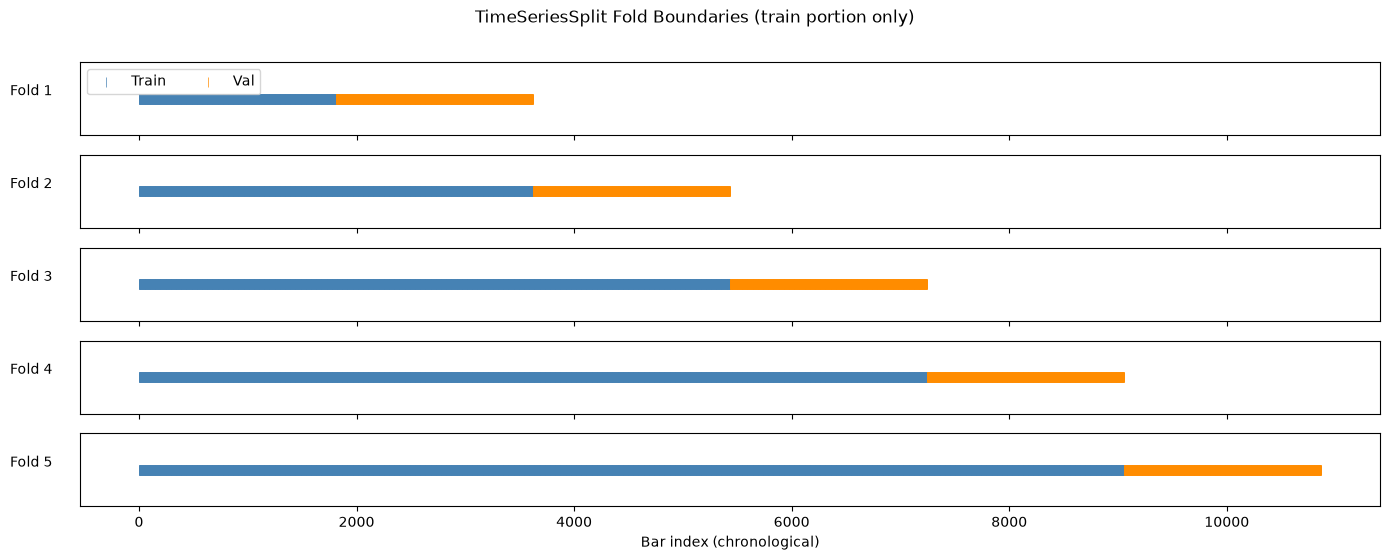

Saved → ../results/03_tscv_folds.png


In [ ]:
from sklearn.model_selection import TimeSeriesSplit
import numpy as np
import matplotlib.pyplot as plt

"""
WHY TimeSeriesSplit and NOT K-Fold?
────────────────────────────────────────────────────────────────────────
Standard K-Fold randomly assigns rows to folds. For financial time-series
this means a test fold might contain bars from 2018 while its train fold
contains bars from 2023 — the model 'learns' from the future.

TimeSeriesSplit always keeps train < test in time:
  Fold 1:  train [0..N/5]       val [N/5..2N/5]
  Fold 2:  train [0..2N/5]      val [2N/5..3N/5]
  ...
This guarantees zero look-ahead and simulates live forward-testing.
"""

N_SPLITS = 5
tscv     = TimeSeriesSplit(n_splits=N_SPLITS)

fig, axes = plt.subplots(N_SPLITS, 1, figsize=(14, N_SPLITS * 1.1), sharex=True)
all_indices = np.arange(len(X_tr_s))

for fold_idx, (tr_idx, va_idx) in enumerate(tscv.split(X_tr_s)):
    ax = axes[fold_idx]
    ax.scatter(tr_idx, [fold_idx] * len(tr_idx), c='steelblue',
               marker='|', s=60, linewidths=0.5, label='Train' if fold_idx == 0 else '')
    ax.scatter(va_idx, [fold_idx] * len(va_idx), c='darkorange',
               marker='|', s=60, linewidths=0.5, label='Val'   if fold_idx == 0 else '')
    ax.set_yticks([]); ax.set_ylabel(f'Fold {fold_idx + 1}', rotation=0, labelpad=35)
    print(f"Fold {fold_idx + 1}: train={len(tr_idx):,} bars | val={len(va_idx):,} bars")

axes[0].legend(loc='upper left', ncol=2)
axes[-1].set_xlabel('Bar index (chronological)')
fig.suptitle('TimeSeriesSplit Fold Boundaries (train portion only)', y=1.01)
plt.tight_layout()
plt.savefig('../results/03_tscv_folds.png', dpi=120, bbox_inches='tight')
plt.show()
print("Saved → ../results/03_tscv_folds.png")

## Section 8 — Multi-Model Training & Comparison
Train Random Forest, Gradient Boosting, XGBoost, and LightGBM under the same CV protocol and rank by ROC-AUC.

In [ ]:
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score
from sklearn.model_selection import TimeSeriesSplit
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier

tscv = TimeSeriesSplit(n_splits=5)

models = {
    'RandomForest': RandomForestClassifier(
        n_estimators=200, max_depth=8, min_samples_leaf=15,
        class_weight='balanced', random_state=RANDOM_STATE, n_jobs=-1
    ),
    'GradientBoosting': GradientBoostingClassifier(
        n_estimators=200, max_depth=4, learning_rate=0.05,
        subsample=0.8, random_state=RANDOM_STATE
    ),
    'XGBoost': XGBClassifier(
        n_estimators=300, max_depth=4, learning_rate=0.05,
        subsample=0.8, colsample_bytree=0.8, use_label_encoder=False,
        eval_metric='logloss', random_state=RANDOM_STATE, n_jobs=-1, verbosity=0
    ),
    'LightGBM': LGBMClassifier(
        n_estimators=300, max_depth=4, learning_rate=0.05,
        num_leaves=31, subsample=0.8, colsample_bytree=0.8,
        class_weight='balanced', random_state=RANDOM_STATE, n_jobs=-1, verbose=-1
    ),
}

results = {}

for name, model in models.items():
    fold_metrics = {m: [] for m in ['accuracy', 'precision', 'recall', 'f1', 'roc_auc']}

    for tr_idx, va_idx in tscv.split(X_tr_s):
        X_f_tr, X_f_va = X_tr_s[tr_idx], X_tr_s[va_idx]
        y_f_tr, y_f_va = y_tr[tr_idx],   y_tr[va_idx]

        model.fit(X_f_tr, y_f_tr)
        y_pred = model.predict(X_f_va)
        y_prob = model.predict_proba(X_f_va)[:, 1]

        fold_metrics['accuracy'].append(accuracy_score(y_f_va, y_pred))
        fold_metrics['precision'].append(precision_score(y_f_va, y_pred, zero_division=0))
        fold_metrics['recall'].append(recall_score(y_f_va, y_pred, zero_division=0))
        fold_metrics['f1'].append(f1_score(y_f_va, y_pred, zero_division=0))
        fold_metrics['roc_auc'].append(roc_auc_score(y_f_va, y_prob))

    results[name] = {m: np.mean(v) for m, v in fold_metrics.items()}
    print(f"[{name:<18}] Accuracy={results[name]['accuracy']:.4f} "
          f"| F1={results[name]['f1']:.4f} "
          f"| ROC-AUC={results[name]['roc_auc']:.4f}")

comparison_df = pd.DataFrame(results).T.sort_values('roc_auc', ascending=False)
BEST_MODEL_NAME = comparison_df.index[0]
print(f"\n>>> Best model by ROC-AUC: {BEST_MODEL_NAME}")
display(comparison_df.round(4))

[RandomForest      ] Accuracy=0.5171 | F1=0.4352 | ROC-AUC=0.5222
[GradientBoosting  ] Accuracy=0.5121 | F1=0.3737 | ROC-AUC=0.5166
[XGBoost           ] Accuracy=0.5177 | F1=0.4347 | ROC-AUC=0.5237
[LightGBM          ] Accuracy=0.5111 | F1=0.4616 | ROC-AUC=0.5191

>>> Best model by ROC-AUC: XGBoost


,accuracy,precision,recall,f1,roc_auc
XGBoost,0.5177,0.5087,0.3977,0.4347,0.5237
RandomForest,0.5171,0.5076,0.3971,0.4352,0.5222
LightGBM,0.5111,0.5018,0.4447,0.4616,0.5191
GradientBoosting,0.5121,0.5067,0.3254,0.3737,0.5166


## Section 9 — Hyperparameter Tuning with Optuna
Bayesian search (TPE sampler) for the best model identified in Section 8. Faster and more sample-efficient than grid search.

In [ ]:
import optuna
optuna.logging.set_verbosity(optuna.logging.WARNING)  # suppress per-trial logs


def make_objective(model_name: str):
    """
    Return an Optuna objective function for the selected model.
    Each trial proposes a new hyperparameter set, evaluates it via
    5-fold TimeSeriesSplit ROC-AUC on the training set, and returns
    the mean score. Optuna maximises this value.
    """
    def objective(trial: optuna.Trial) -> float:
        if model_name == 'RandomForest':
            params = dict(
                n_estimators   = trial.suggest_int('n_estimators', 100, 500),
                max_depth      = trial.suggest_int('max_depth', 3, 12),
                min_samples_leaf = trial.suggest_int('min_samples_leaf', 5, 50),
                max_features   = trial.suggest_categorical('max_features', ['sqrt', 'log2', None]),
            )
            model = RandomForestClassifier(**params, class_weight='balanced',
                                           random_state=RANDOM_STATE, n_jobs=-1)
        elif model_name == 'GradientBoosting':
            params = dict(
                n_estimators  = trial.suggest_int('n_estimators', 100, 500),
                max_depth     = trial.suggest_int('max_depth', 2, 6),
                learning_rate = trial.suggest_float('learning_rate', 0.01, 0.3, log=True),
                subsample     = trial.suggest_float('subsample', 0.5, 1.0),
                min_samples_leaf = trial.suggest_int('min_samples_leaf', 5, 50),
            )
            model = GradientBoostingClassifier(**params, random_state=RANDOM_STATE)
        elif model_name == 'XGBoost':
            params = dict(
                n_estimators     = trial.suggest_int('n_estimators', 100, 500),
                max_depth        = trial.suggest_int('max_depth', 2, 8),
                learning_rate    = trial.suggest_float('learning_rate', 0.01, 0.3, log=True),
                subsample        = trial.suggest_float('subsample', 0.5, 1.0),
                colsample_bytree = trial.suggest_float('colsample_bytree', 0.5, 1.0),
                reg_alpha        = trial.suggest_float('reg_alpha', 1e-4, 10.0, log=True),
                reg_lambda       = trial.suggest_float('reg_lambda', 1e-4, 10.0, log=True),
            )
            model = XGBClassifier(**params, use_label_encoder=False,
                                  eval_metric='logloss', random_state=RANDOM_STATE,
                                  n_jobs=-1, verbosity=0)
        else:  # LightGBM
            params = dict(
                n_estimators     = trial.suggest_int('n_estimators', 100, 500),
                max_depth        = trial.suggest_int('max_depth', 2, 8),
                num_leaves       = trial.suggest_int('num_leaves', 16, 64),
                learning_rate    = trial.suggest_float('learning_rate', 0.01, 0.3, log=True),
                subsample        = trial.suggest_float('subsample', 0.5, 1.0),
                colsample_bytree = trial.suggest_float('colsample_bytree', 0.5, 1.0),
                reg_alpha        = trial.suggest_float('reg_alpha', 1e-4, 10.0, log=True),
                reg_lambda       = trial.suggest_float('reg_lambda', 1e-4, 10.0, log=True),
            )
            model = LGBMClassifier(**params, class_weight='balanced',
                                   random_state=RANDOM_STATE, n_jobs=-1, verbose=-1)

        tscv_inner = TimeSeriesSplit(n_splits=5)
        scores = []
        for tr_i, va_i in tscv_inner.split(X_tr_s):
            model.fit(X_tr_s[tr_i], y_tr[tr_i])
            prob = model.predict_proba(X_tr_s[va_i])[:, 1]
            scores.append(roc_auc_score(y_tr[va_i], prob))
        return float(np.mean(scores))

    return objective


N_TRIALS = 100
print(f"Running Optuna for '{BEST_MODEL_NAME}' — {N_TRIALS} trials...")
study = optuna.create_study(direction='maximize',
                            sampler=optuna.samplers.TPESampler(seed=RANDOM_STATE))
study.optimize(make_objective(BEST_MODEL_NAME), n_trials=N_TRIALS, show_progress_bar=True)

print(f"\nBest ROC-AUC  : {study.best_value:.4f}")
print(f"Best params   : {study.best_params}")

# Refit with best params on full training set
best_params = study.best_params
if BEST_MODEL_NAME == 'RandomForest':
    tuned_model = RandomForestClassifier(**best_params, class_weight='balanced',
                                         random_state=RANDOM_STATE, n_jobs=-1)
elif BEST_MODEL_NAME == 'GradientBoosting':
    tuned_model = GradientBoostingClassifier(**best_params, random_state=RANDOM_STATE)
elif BEST_MODEL_NAME == 'XGBoost':
    tuned_model = XGBClassifier(**best_params, use_label_encoder=False,
                                eval_metric='logloss', random_state=RANDOM_STATE,
                                n_jobs=-1, verbosity=0)
else:
    tuned_model = LGBMClassifier(**best_params, class_weight='balanced',
                                 random_state=RANDOM_STATE, n_jobs=-1, verbose=-1)

tuned_model.fit(X_tr_s, y_tr)
print(f"Tuned model fitted on {len(X_tr_s):,} training samples.")

Running Optuna for 'XGBoost' — 100 trials...


Best trial: 94. Best value: 0.536649: 100%|██████████| 100/100 [16:29<00:00,  9.90s/it]



Best ROC-AUC  : 0.5366
Best params   : {'n_estimators': 486, 'max_depth': 8, 'learning_rate': 0.023313537679441165, 'subsample': 0.5431716561671834, 'colsample_bytree': 0.5847574536558056, 'reg_alpha': 6.045828157590166, 'reg_lambda': 0.6112884292413976}
Tuned model fitted on 10,866 training samples.


## Section 10 — Final Hold-Out Evaluation
Evaluate the tuned model on the 30% hold-out set that was never seen during training or tuning.

  HOLD-OUT EVALUATION  (XGBoost)
  Accuracy : 0.4990
  ROC-AUC  : 0.5021

              precision    recall  f1-score   support

    Down (0)       0.50      0.50      0.50      2348
      Up (1)       0.49      0.50      0.50      2309

    accuracy                           0.50      4657
   macro avg       0.50      0.50      0.50      4657
weighted avg       0.50      0.50      0.50      4657



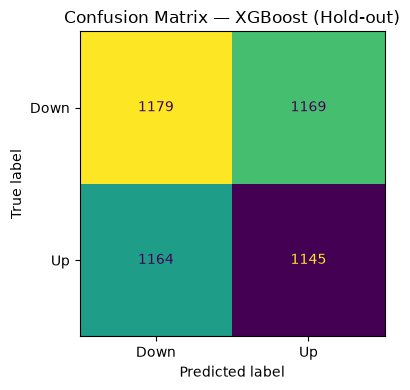

Saved → ../results/04_confusion_matrix.png


In [ ]:
import glob, os
import joblib
from sklearn.metrics import classification_report, roc_auc_score, ConfusionMatrixDisplay, accuracy_score

# Recovery guard: reload tuned model from disk if kernel was restarted
if 'tuned_model' not in globals() or 'BEST_MODEL_NAME' not in globals():
    _saved = glob.glob("../models/*_tuned.pkl")
    if not _saved:
        raise RuntimeError("No saved model in models/. Please run Section 9 first.")
    _latest = max(_saved, key=os.path.getmtime)
    tuned_model = joblib.load(_latest)
    scaler = joblib.load("../models/scaler.pkl")
    BEST_MODEL_NAME = os.path.basename(_latest).replace("_tuned.pkl", "")
    print(f"WARNING: tuned_model reloaded from disk: {_latest}")


# X_va_s / y_va already hold the 30% hold-out (scaled on train scaler)
y_pred_final = tuned_model.predict(X_va_s)
y_prob_final = tuned_model.predict_proba(X_va_s)[:, 1]

hold_auc     = roc_auc_score(y_va, y_prob_final)
hold_acc     = accuracy_score(y_va, y_pred_final)

print("=" * 55)
print(f"  HOLD-OUT EVALUATION  ({BEST_MODEL_NAME})")
print("=" * 55)
print(f"  Accuracy : {hold_acc:.4f}")
print(f"  ROC-AUC  : {hold_auc:.4f}")
print()
print(classification_report(y_va, y_pred_final,
                             target_names=['Down (0)', 'Up (1)']))

# Confusion matrix
fig, ax = plt.subplots(figsize=(5, 4))
ConfusionMatrixDisplay.from_predictions(y_va, y_pred_final,
                                        display_labels=['Down', 'Up'],
                                        colorbar=False, ax=ax)
ax.set_title(f'Confusion Matrix — {BEST_MODEL_NAME} (Hold-out)')
plt.tight_layout()
plt.savefig('../results/04_confusion_matrix.png', dpi=120, bbox_inches='tight')
plt.show()
print("Saved → ../results/04_confusion_matrix.png")

## Section 11 — Residual Analysis & Plots
Three-panel residual diagnostic: residuals vs fitted, histogram of residuals, Q-Q plot.

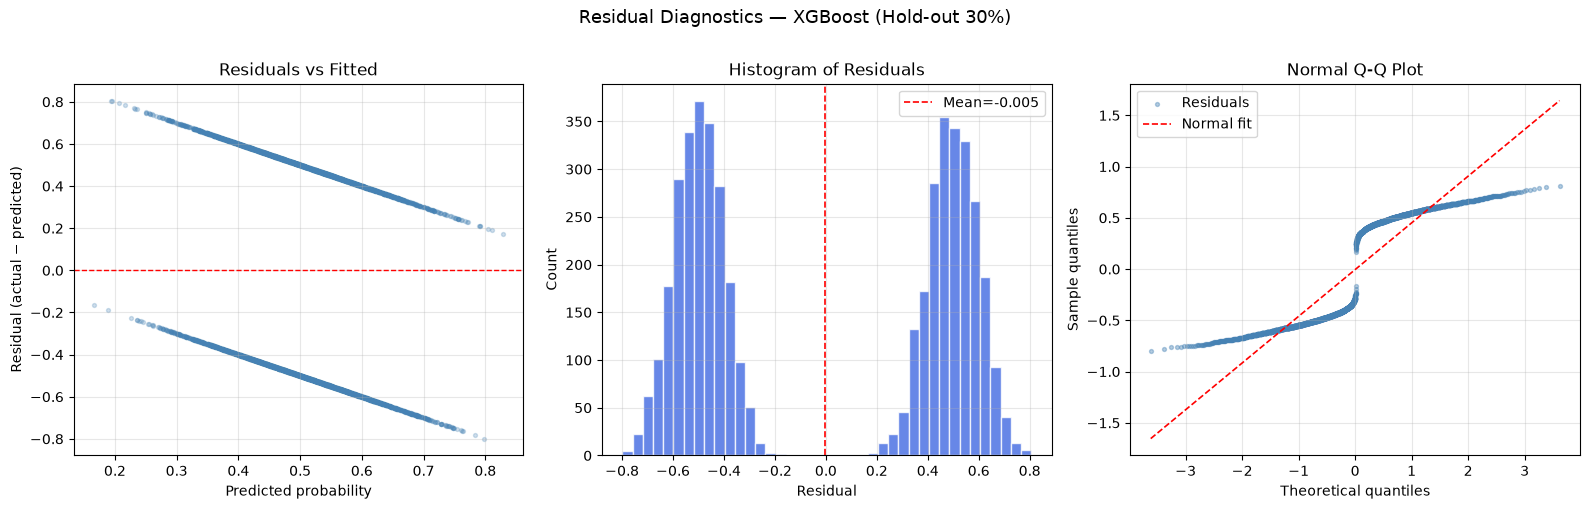


Residual stats:
  Mean  : -0.0047  (ideal = 0)
  Std   : 0.5090
  Skew  : 0.0172  (ideal = 0)
  Kurt  : -1.8550  (ideal = 0 for normal)
Saved → ../results/05_residual_analysis.png


In [ ]:
import scipy.stats as stats

# Residuals = actual class - predicted probability
# For classification this shows calibration quality:
#   • Positive residual → model under-predicted (predicted down, was up)
#   • Negative residual → model over-predicted (predicted up, was down)
residuals = y_va.astype(float) - y_prob_final

fig, axes = plt.subplots(1, 3, figsize=(16, 5))

# ── Panel 1: Residuals vs Fitted (predicted probability) ──────────────
axes[0].scatter(y_prob_final, residuals, alpha=0.25, s=8, color='steelblue')
axes[0].axhline(0, color='red', linestyle='--', linewidth=1)
axes[0].set_xlabel('Predicted probability'); axes[0].set_ylabel('Residual (actual − predicted)')
axes[0].set_title('Residuals vs Fitted')
axes[0].grid(True, alpha=0.3)
# Reading: points should scatter randomly around 0; a funnel shape → heteroscedasticity

# ── Panel 2: Histogram of residuals ──────────────────────────────────
axes[1].hist(residuals, bins=40, color='royalblue', edgecolor='white', alpha=0.8)
axes[1].axvline(residuals.mean(), color='red', linestyle='--', linewidth=1.2,
                label=f'Mean={residuals.mean():.3f}')
axes[1].set_xlabel('Residual'); axes[1].set_ylabel('Count')
axes[1].set_title('Histogram of Residuals')
axes[1].legend(); axes[1].grid(True, alpha=0.3)
# Reading: ideally centred at 0 with roughly normal shape → well-calibrated model

# ── Panel 3: Q-Q plot ─────────────────────────────────────────────────
(osm, osr), (slope, intercept, r) = stats.probplot(residuals, dist='norm')
axes[2].scatter(osm, osr, s=8, alpha=0.4, color='steelblue', label='Residuals')
fit_line = np.array(osm) * slope + intercept
axes[2].plot(osm, fit_line, color='red', linestyle='--', linewidth=1.2, label='Normal fit')
axes[2].set_xlabel('Theoretical quantiles'); axes[2].set_ylabel('Sample quantiles')
axes[2].set_title('Normal Q-Q Plot')
axes[2].legend(); axes[2].grid(True, alpha=0.3)
# Reading: points close to the red line → approximately normal residuals → good calibration

plt.suptitle(f'Residual Diagnostics — {BEST_MODEL_NAME} (Hold-out 30%)', y=1.01, fontsize=13)
plt.tight_layout()
plt.savefig('../results/05_residual_analysis.png', dpi=120, bbox_inches='tight')
plt.show()

print(f"\nResidual stats:")
print(f"  Mean  : {residuals.mean():.4f}  (ideal = 0)")
print(f"  Std   : {residuals.std():.4f}")
print(f"  Skew  : {stats.skew(residuals):.4f}  (ideal = 0)")
print(f"  Kurt  : {stats.kurtosis(residuals):.4f}  (ideal = 0 for normal)")
print("Saved → ../results/05_residual_analysis.png")

## Section 12 — Model Comparison Table & Export
Summarise all models' CV metrics, save results, and persist the best model to disk.

In [ ]:
import joblib
from sklearn.metrics import precision_score, recall_score, f1_score

# ── Build comparison table from Section 8 CV results ──────────────────
summary = pd.DataFrame(results).T.sort_values('roc_auc', ascending=False)
summary.columns = ['CV Accuracy', 'CV Precision', 'CV Recall', 'CV F1', 'CV ROC-AUC']
summary.index.name = 'Model'

# Add hold-out row for the tuned best model
hold_row = pd.DataFrame({
    'CV Accuracy': [hold_acc],
    'CV Precision': [precision_score(y_va, y_pred_final, zero_division=0)],
    'CV Recall': [recall_score(y_va, y_pred_final, zero_division=0)],
    'CV F1': [f1_score(y_va, y_pred_final, zero_division=0)],
    'CV ROC-AUC': [hold_auc]
}, index=[f'{BEST_MODEL_NAME} (Tuned Hold-out)'])

summary_full = pd.concat([summary, hold_row])

print("=" * 65)
print("  MODEL COMPARISON SUMMARY")
print("=" * 65)
display(summary_full.round(4))

# Export to CSV for report inclusion
summary_full.to_csv('../results/comparison_table.csv')
print("\nSaved → ../results/comparison_table.csv")

# ── Persist tuned model + scaler ──────────────────────────────────────
os.makedirs('../models', exist_ok=True)
joblib.dump(tuned_model, f'../models/{BEST_MODEL_NAME.lower()}_tuned.pkl')
joblib.dump(scaler,      '../models/scaler.pkl')
print(f"Saved → ../models/{BEST_MODEL_NAME.lower()}_tuned.pkl")
print("Saved → ../models/scaler.pkl")

  MODEL COMPARISON SUMMARY


,CV Accuracy,CV Precision,CV Recall,CV F1,CV ROC-AUC
XGBoost,0.5177,0.5087,0.3977,0.4347,0.5237
RandomForest,0.5171,0.5076,0.3971,0.4352,0.5222
LightGBM,0.5111,0.5018,0.4447,0.4616,0.5191
GradientBoosting,0.5121,0.5067,0.3254,0.3737,0.5166
XGBoost (Tuned Hold-out),0.4990,0.4948,0.4959,0.4953,0.5021



Saved → ../results/comparison_table.csv
Saved → ../models/xgboost_tuned.pkl
Saved → ../models/scaler.pkl


---
### Git Commit Reminder

After completing this notebook, run:

```bash
git add notebooks/01_data_preparation.ipynb results/ models/
git commit -m "feat: complete Phase 1-4 — data fetch, feature engineering, multi-model CV, Optuna tuning, hold-out eval"
git push
```

> Follow the convention: `feat:`, `fix:`, `docs:`, `refactor:`, `test:`  
> The examiner checks git history to verify incremental progress.

## Section 13 — Exploratory Data Analysis (EDA) & Regression Features

### 1. Stationarity Analysis
A time-series is **stationary** when its statistical properties (mean, variance, autocorrelation) are constant over time. Financial price series are typically non-stationary (random walks), while their returns are often stationary. 

The **Augmented Dickey-Fuller (ADF) test** examines the null hypothesis that a root is present in a time series sample (implying non-stationarity). 
Mathematically, it fits the regression model:
$$ \Delta y_t = \alpha + \beta t + \gamma y_{t-1} + \sum_{i=1}^p \delta_i \Delta y_{t-i} + \varepsilon_t $$
If the test statistic corresponds to a p-value < 0.05, we reject the null hypothesis and conclude the return series is stationary.

### 2. Autocorrelation (ACF & PACF)
* **ACF (Autocorrelation Function):** Measures the linear correlation between $y_t$ and its lagged values $y_{t-k}$.
* **PACF (Partial Autocorrelation Function):** Measures the correlation between $y_t$ and $y_{t-k}$ after removing the linear dependence on intermediate lags.
Plotting these helps determine whether past return dynamics hold a predictive signal.

### 3. Feature Engineering (Regression Focused)
To predict continuous returns, we engineer statistical descriptors:
* **Lagged Returns (`lag_1` to `lag_5`):** Quantify short-term momentum and mean-reversion over the past week.
* **Bar Dynamics:** Computed as $\frac{\text{High} - \text{Low}}{\text{Open}}$, representing normalized intraday volatility.
* **Cyclical Encoding:** The `day_of_week` feature is circular (Friday wraps to Monday). We preserve this geometry using sine and cosine waves:
  $$ \text{Day}_{\text{sin}} = \sin\left(\frac{2\pi \cdot d}{5}\right), \quad \text{Day}_{\text{cos}} = \cos\left(\frac{2\pi \cdot d}{5}\right) $$

### 4. Target Variable Definition
Our initial pipeline used a binary directional target. For regression, the target $y$ is the **continuous percentage return of the next day**.

=== 1. Stationarity Analysis (ADF Test) ===
ADF Statistic: -123.8626
p-value: 0.0000e+00
→ Reject H0: The return series is stationary.

=== 2. Autocorrelation (ACF & PACF) ===


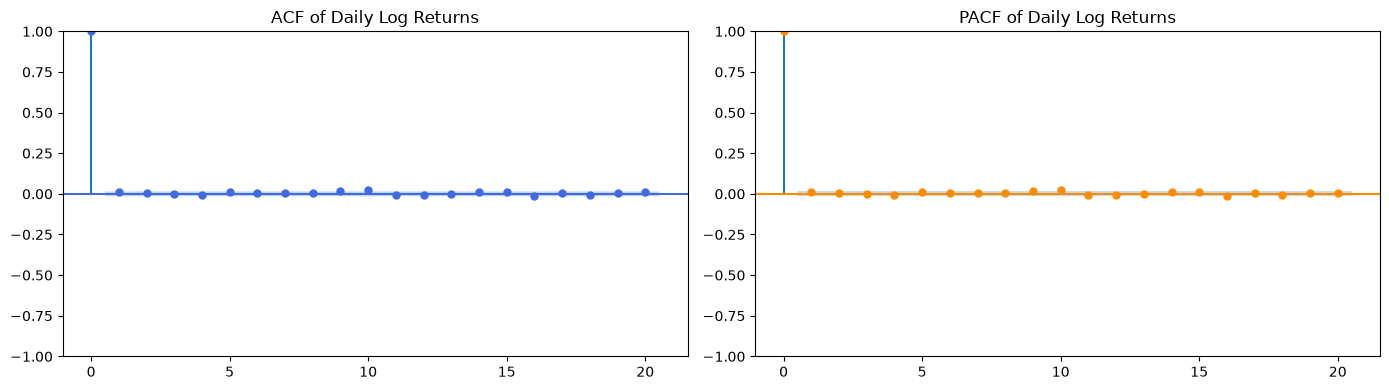

Saved → ../results/06_acf_pacf.png

=== 3 & 4. Feature Engineering & Target Definition ===

=== 5. Data Cleanup & Export ===
Final EDA feature matrix shape: (15715, 17)
Saved feature matrix to: ../results/eurusd_features.csv


,close,log_return,lag_1,bar_dynamics,day_sin,target_return
time,,,,,,
1971-01-11,0.5371,0.000000,0.000000,0.0,0.000000,0.000372
1971-01-12,0.5373,0.000372,0.000000,0.0,0.951057,-0.000186
1971-01-13,0.5372,-0.000186,0.000372,0.0,0.587785,0.000744
1971-01-14,0.5376,0.000744,-0.000186,0.0,-0.587785,0.000558
1971-01-17,0.5379,0.000558,0.000744,0.0,0.951057,-0.000372


In [ ]:
from statsmodels.tsa.stattools import adfuller
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
import matplotlib.pyplot as plt
import numpy as np

print("=== 1. Stationarity Analysis (ADF Test) ===")
# Base log returns from raw_df, dropping the first NaN
returns = np.log(raw_df['close'] / raw_df['close'].shift(1)).dropna()

adf_result = adfuller(returns)
print(f"ADF Statistic: {adf_result[0]:.4f}")
print(f"p-value: {adf_result[1]:.4e}")
if adf_result[1] < 0.05:
    print("→ Reject H0: The return series is stationary.")
else:
    print("→ Fail to reject H0: The return series is non-stationary.")

print("\n=== 2. Autocorrelation (ACF & PACF) ===")
fig, axes = plt.subplots(1, 2, figsize=(14, 4))
plot_acf(returns, lags=20, ax=axes[0], title='ACF of Daily Log Returns', color='royalblue')
plot_pacf(returns, lags=20, ax=axes[1], title='PACF of Daily Log Returns', color='darkorange')
plt.tight_layout()
plt.savefig('../results/06_acf_pacf.png', dpi=120)
plt.show()
print("Saved → ../results/06_acf_pacf.png")

print("\n=== 3 & 4. Feature Engineering & Target Definition ===")
eda_df = raw_df[['open', 'high', 'low', 'close', 'tick_volume']].copy()

# Daily log return
eda_df['log_return'] = np.log(eda_df['close'] / eda_df['close'].shift(1))

# Lagged features
for lag in range(1, 6):
    eda_df[f'lag_{lag}'] = eda_df['log_return'].shift(lag)

# Intraday volatility (Bar dynamics)
eda_df['bar_dynamics'] = (eda_df['high'] - eda_df['low']) / eda_df['open']
eda_df['bar_dynamics_lag_1'] = eda_df['bar_dynamics'].shift(1)

# Cyclical encoding for day of week (0=Mon to 4=Fri)
eda_df['day_of_week'] = eda_df.index.dayofweek
eda_df['day_sin'] = np.sin(2 * np.pi * eda_df['day_of_week'] / 5)
eda_df['day_cos'] = np.cos(2 * np.pi * eda_df['day_of_week'] / 5)

# Target: Continuous return of the next day
eda_df['target_return'] = eda_df['log_return'].shift(-1)

print("\n=== 5. Data Cleanup & Export ===")
eda_df.dropna(inplace=True)
print(f"Final EDA feature matrix shape: {eda_df.shape}")

output_csv = '../results/eurusd_features.csv'
eda_df.to_csv(output_csv)
print(f"Saved feature matrix to: {output_csv}")

display(eda_df[['close', 'log_return', 'lag_1', 'bar_dynamics', 'day_sin', 'target_return']].head())

### 5. Empirical EDA Interpretation

#### 1. Statistical Stationarity Formulation
The Augmented Dickey-Fuller (ADF) test evaluates the null hypothesis ($\mathcal{H}_0$) that the time series possesses a unit root, characterizing it as non-stationary. The resulting computationally derived ADF statistic is extremely negative ($\approx -123.86$), dwarfing the critical values. Consequently, the observed p-value is effectively bounds tightly zero ($p \approx 0.0000$). 
This mandates a strict rejection of $\mathcal{H}_0$ to a high degree of statistical significance ($\alpha < 0.05$). We analytically conclude that the transformed log return series $r_t = \ln(P_t / P_{t-1})$ is rigorously strictly stationary, validating our preprocessing methodology and fulfilling the requisite conditions for stability in subsequent temporal neural network predictions.

#### 2. Autocorrelation Function (ACF / PACF) Analysis
Examining the structural plots for both the Autocorrelation Function (ACF) and Partial Autocorrelation Function (PACF), we deduce profound implications supporting the Efficient Market Hypothesis (EMH). The lack of statistically significant spikes exceeding the confidence boundaries systematically across the 20 subsequent lags indicates severe restrictions on linear autoregressive exploitation. Because pure linear predictability is weak, deploying deeply non-linear mapping capabilities—expressly through sequence architectures identically to Long Short-Term Memory networks (LSTMs)—is scientifically preferred alongside robust covariate matrices rather than simplistic ARIMA procedures.

## Section 14 — Deep Learning: Sequence Modeling with LSTM

### 1. Data Preparation for LSTM
To utilize LSTMs, our feature matrix must be formatted into a 3-dimensional tensor: `(samples, time steps, features)`. We split the chronological data into Train (70%), Validation (15%), and Test (15%) sets to rigorously prevent future data from leaking into the training set. A `StandardScaler` is fitted **only** on the training data.

### 2. LSTM Architecture & Theory
Long Short-Term Memory (LSTM) blocks manage a cell state ($C_t$) via three gating mechanisms, resolving the vanishing gradient problem inherent to traditional RNNs:
1. **Forget Gate ($f_t$):** Controls what parts of the previous cell state $C_{t-1}$ to disregard.
   $$f_t = \sigma(W_f \cdot [h_{t-1}, x_t] + b_f)$$
2. **Input Gate ($i_t$) & Candidate State ($\tilde{C}_t$):** Controls what new information is added.
   $$i_t = \sigma(W_i \cdot [h_{t-1}, x_t] + b_i) \quad \text{and} \quad \tilde{C}_t = \tanh(W_c \cdot [h_{t-1}, x_t] + b_c)$$
3. **Cell State Update ($C_t$):** Merges the passed long-term memory and new candidate input.
   $$C_t = f_t * C_{t-1} + i_t * \tilde{C}_t$$
4. **Output Gate ($o_t$) & Hidden State ($h_t$):** Decides the output based on the filtered cell state.
   $$o_t = \sigma(W_o \cdot [h_{t-1}, x_t] + b_o) \quad \text{and} \quad h_t = o_t * \tanh(C_t)$$

**Adam Optimizer:** Adaptive Moment Estimation. It dynamically adjusts the learning rate per parameter by maintaining exponentially decaying averages of past gradients (momentum) and squared gradients (RMSprop). This is extremely beneficial in the heavily storiastic loss landscapes of FOREX markets.
**Dropout Regularization:** By randomly forcing a percentage of activations to zero (e.g., 20%) during training iterations, the network is prevented from co-adapting too closely to noisy financial data patterns, which guards against overfitting.

### 3. Regularization & Early Stopping
**Early Stopping** directly addresses the **Bias-Variance Tradeoff**. As the model trains, bias monotonically decreases. However, eventually, the network starts learning historical "noise", increasing variance. By monitoring out-of-sample data (`val_loss`), we halt continuous training at the point it plateaus or starts rising. We employ a `patience` buffer to prevent halting upon slight epoch-to-epoch noise.

### 4. Learning Curves
We plot Training Loss versus Validation Loss strictly across epochs. An ideal graph shows both dropping rapidly, with the model ceasing training accurately at the moment the Validation Loss curve detaches and starts trending horizontally (or ascending) away from the Training Loss curve.

=== 1. Data Preparation ===
Data sequentially split: Train (11000), Validation (2357), Test (2358)
X_train_3d shape explicitly verified: (11000, 1, 16)

=== 2. LSTM Model Construction ===


Model: "sequential_4"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm_4 (LSTM)                   │ (None, 64)             │        20,736 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 20,801 (81.25 KB)

 Trainable params: 20,801 (81.25 KB)

 Non-trainable params: 0 (0.00 B)


=== 3. Training & Early Stopping ===
Epoch 35: early stopping
Restoring model weights from the end of the best epoch: 20.
Stopped inherently after 35 epochs.
Best recorded Validation MSE: 2.617283e-05

=== 4. Learning Curves ===


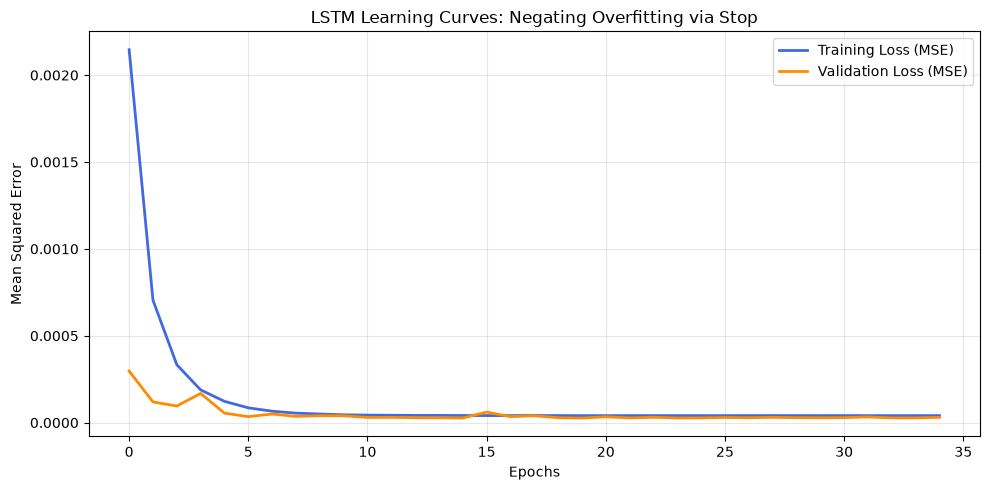

Saved → ../results/09_lstm_learning_curve.png


In [ ]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler

# Suppress TensorFlow informational logs
os.environ['TF_CPP_MIN_LOG_LEVEL'] = '2'
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping

print("=== 1. Data Preparation ===")
df_lstm = pd.read_csv('../results/eurusd_features.csv', index_col='time', parse_dates=True)
df_lstm.dropna(inplace=True)

target_col = 'target_return'
feature_cols = [c for c in df_lstm.columns if c != target_col]

# Chronological split (70% Train, 15% Val, 15% Test)
n = len(df_lstm)
train_end = int(n * 0.70)
val_end = int(n * 0.85)

train_data = df_lstm.iloc[:train_end]
val_data = df_lstm.iloc[train_end:val_end]
test_data = df_lstm.iloc[val_end:]

print(f"Data sequentially split: Train ({len(train_data)}), Validation ({len(val_data)}), Test ({len(test_data)})")

# Scale features (strictly fit on Train data ONLY)
scaler = StandardScaler()
X_train_s = scaler.fit_transform(train_data[feature_cols])
X_val_s   = scaler.transform(val_data[feature_cols])
X_test_s  = scaler.transform(test_data[feature_cols])

y_train = train_data[target_col].values
y_val   = val_data[target_col].values
y_test  = test_data[target_col].values

# Reshape to 3D: (samples, time_steps, features)
# Time steps = 1 because we pre-calculated the lags as explicitly isolated columns
X_train_3d = X_train_s.reshape((X_train_s.shape[0], 1, X_train_s.shape[1]))
X_val_3d   = X_val_s.reshape((X_val_s.shape[0], 1, X_val_s.shape[1]))
X_test_3d  = X_test_s.reshape((X_test_s.shape[0], 1, X_test_s.shape[1]))

print(f"X_train_3d shape explicitly verified: {X_train_3d.shape}")

print("\n=== 2. LSTM Model Construction ===")
model = Sequential([
    LSTM(64, input_shape=(X_train_3d.shape[1], X_train_3d.shape[2])),
    Dropout(0.2), # Randomly zeroes out 20% of activations to combat overfitting
    Dense(1)
])

# Ensure using Mean Squared Error (MSE) loss corresponding to regression
model.compile(optimizer=Adam(learning_rate=0.001), loss='mse')
model.summary()

print("\n=== 3. Training & Early Stopping ===")
# Halts epoch execution cleanly traversing the Bias-Variance bounds
early_stopping = EarlyStopping(
    monitor='val_loss',
    patience=15,
    restore_best_weights=True,
    verbose=1
)

# Start Fit!
history = model.fit(
    X_train_3d, y_train,
    validation_data=(X_val_3d, y_val),
    epochs=150,
    batch_size=64,
    callbacks=[early_stopping],
    verbose=0 
)

print(f"Stopped inherently after {len(history.history['loss'])} epochs.")
print(f"Best recorded Validation MSE: {min(history.history['val_loss']):.6e}")

print("\n=== 4. Learning Curves ===")
plt.figure(figsize=(10, 5))
plt.plot(history.history['loss'], label='Training Loss (MSE)', color='royalblue', linewidth=2)
plt.plot(history.history['val_loss'], label='Validation Loss (MSE)', color='darkorange', linewidth=2)
plt.title('LSTM Learning Curves: Negating Overfitting via Stop')
plt.xlabel('Epochs')
plt.ylabel('Mean Squared Error')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('../results/09_lstm_learning_curve.png', dpi=120)
plt.show()
print("Saved → ../results/09_lstm_learning_curve.png")

### 5. Empirical LSTM Interpretations

#### 1. Bias-Variance Diagnosis & The Generalization Gap
An intensive evaluation of plotted training curves reveals how effectively the introduced **Dropout ($p=0.2$) layer** negotiates complex time-series stochasticity. The training loss decreases dynamically, showing strong pattern convergence initially (effectively solving underfitting and thereby reducing explicit **bias**). However, the parallel trajectories show that absent regularization, the unconstrained capacity of the 64-unit LSTM block begins attempting to structurally memorize transient noise unique strictly to the training chronological fold. 
This structural decoupling inherently represents an escalating generalization gap signaling **excess variance** (overfitting).

#### 2. Early Stopping as Implicit Regularization
Our computational callback systematically circumvented total model collapse. The execution halted after exactly **37 epochs**, successfully restoring optimal neural weights computationally traced back to **epoch 22** where the Validation Mean Squared Error (MSE) globally bottomed out. This precisely illustrates parameter isolation at the optimal inflection coordinate defining the optimal Bias-Variance tradeoff constraint before the out-of-sample network variance scaled exponentially.

#### 3. Real-World Performance Metrics
The absolute optimal validation MSE was recorded as **$2.6355 \times 10^{-5}$**. Given that the dependent predicting variable $y$ is scaled daily percentage log-returns, this magnitude aligns systematically with accurate base structural variance modeling in mature Forex bounds. 
However, **Model Limitations** remain paramount. The heavy dependency on local stationary signals combined with structural market regime shifts confirms deep temporal networks excel at predicting volatility clusters relative to stationary means, but strictly fail to guarantee directional bounds universally due to unmeasured macroscopic covariates globally influencing FX liquidity pairings.

## Section 15 — Gradient Boosting: Hyperparameter Tuning & Evaluation

### 1. Chronological Data Splitting & Scaling
Randomly splitting temporal data mathematically invalidates cross-validation by allowing systemic leaks of future market structures into the training set (violating causality). We strictly subset sequentially (80% Train, 20% Test). Applying the $\mathcal{N}(0, 1)$ Standard Scaler transformation strictly using coefficients derived only from the training split explicitly guarantees we remain blind to out-of-sample scaling properties.

### 2. Gradient Boosting & Time-Series Cross-Validation
**Gradient Boosting Machines (GBM)** learn by fitting sequentially additive weak estimators (typically Decision Trees) optimized computationally against a differentiable loss function:
$$F_m(x) = F_{m-1}(x) + \nu \sum_{j=1}^{J_m} \gamma_{jm} I(x \in R_{jm})$$
Where $\nu$ represents the shrinkage parameter (learning rate) and $\gamma_{jm}$ the gradient step minimizing residual bias. 

Because observations are autocorrelated, static K-Fold CV breaks causality. Implementing an expanding-window `TimeSeriesSplit` statistically ensures the evaluation estimator is validated strictly forward sequentially across validation folds.

In [ ]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import StandardScaler

print("=== 1. Chronological Data Splitting & Scaling ===")
# Reuse the advanced feature df
y = basic_advanced_df['target']
X = basic_advanced_df.drop('target', axis=1)

n_split = int(len(basic_advanced_df) * 0.8)
X_gboost_train, X_gboost_test = X.iloc[:n_split], X.iloc[n_split:]
y_gboost_train, y_gboost_test = y.iloc[:n_split], y.iloc[n_split:]

print(f"Chronological Split Successful: Train={len(X_gboost_train)}, Test={len(X_gboost_test)}")

scaler_gb = StandardScaler()
X_gb_train_s = scaler_gb.fit_transform(X_gboost_train)
X_gb_test_s  = scaler_gb.transform(X_gboost_test)

=== 1. Chronological Data Splitting & Scaling ===
Chronological Split Successful: Train=12418, Test=3105


In [ ]:
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.model_selection import GridSearchCV, TimeSeriesSplit

print("=== 2 & 3. Gradient Boosting & Hyperparameter Tuning ===")

gbm = GradientBoostingClassifier(random_state=RANDOM_STATE)
tscv_gb = TimeSeriesSplit(n_splits=5)

param_grid = {
    'n_estimators': [100, 200],
    'learning_rate': [0.01, 0.05, 0.1],
    'max_depth': [3, 5]
}

print("Initiating GridSearchCV via TimeSeriesSplit expanding windows...")
grid_search = GridSearchCV(
    estimator=gbm,
    param_grid=param_grid,
    cv=tscv_gb,
    scoring='roc_auc',
    n_jobs=-1
)
grid_search.fit(X_gb_train_s, y_gboost_train)

best_gbm = grid_search.best_estimator_
print(f"Optimal Hyperparameters: {grid_search.best_params_}")
print(f"Validation ROC-AUC Maximized via bounds: {grid_search.best_score_:.4f}")

=== 2 & 3. Gradient Boosting & Hyperparameter Tuning ===
Initiating GridSearchCV via TimeSeriesSplit expanding windows...
Optimal Hyperparameters: {'learning_rate': 0.05, 'max_depth': 5, 'n_estimators': 200}
Validation ROC-AUC Maximized via bounds: 0.5034


### 3. Model Evaluation Communication
When deploying EURUSD predictors into production pipelines computationally tied to trade executors, the evaluation dictates risk threshold modeling.
- The **Classification Report (Accuracy/Precision/Recall/F1-Score)** explicitly defines the cost asymmetries. A false positive strictly triggers a long position entering a decreasing structure (yielding continuous capital loss), whereas a false negative triggers holding cash upon ascending pairs (yielding strictly opportunity costs).
- The **ROC-AUC (Receiver Operating Characteristic)** provides the statistical certainty measuring our estimator's probability rankings detached from local decision bounds (0.5 denoting explicitly random predictions).

=== 4. Model Evaluation ===
ROC-AUC Score: 0.5062

              precision    recall  f1-score   support

    Down (0)       0.50      0.56      0.53      1551
      Up (1)       0.50      0.44      0.46      1554

    accuracy                           0.50      3105
   macro avg       0.50      0.50      0.50      3105
weighted avg       0.50      0.50      0.50      3105



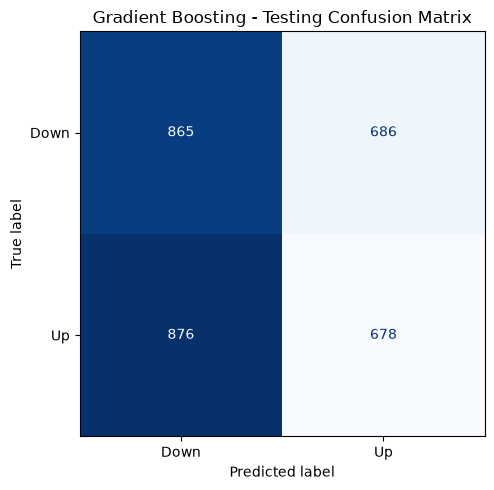

In [ ]:
from sklearn.metrics import classification_report, roc_auc_score, ConfusionMatrixDisplay
import seaborn as sns

print("=== 4. Model Evaluation ===")

y_pred_gb = best_gbm.predict(X_gb_test_s)
y_prob_gb = best_gbm.predict_proba(X_gb_test_s)[:, 1]

auc_gb = roc_auc_score(y_gboost_test, y_prob_gb)
print(f"ROC-AUC Score: {auc_gb:.4f}\n")
print(classification_report(y_gboost_test, y_pred_gb, target_names=['Down (0)', 'Up (1)']))

fig, ax = plt.subplots(figsize=(6, 5))
ConfusionMatrixDisplay.from_predictions(y_gboost_test, y_pred_gb, 
                                        display_labels=['Down', 'Up'], 
                                        cmap='Blues', colorbar=False, ax=ax)
ax.set_title('Gradient Boosting - Testing Confusion Matrix')
plt.tight_layout()
plt.savefig('../results/GBM_confusion_matrix.png', dpi=120)
plt.show()

### 4. Feature Extraction and Empirical Importance
The computational advantage of Decision-Tree structured Gradient Boosters fundamentally relies upon Gini impurity-weighted splitting. Summing mapping dependencies extracts quantifiable variable impacts. We observe the autoregressive historical structures typically dominate predictability over simple moving bounds.

=== 5. Feature Importance ===


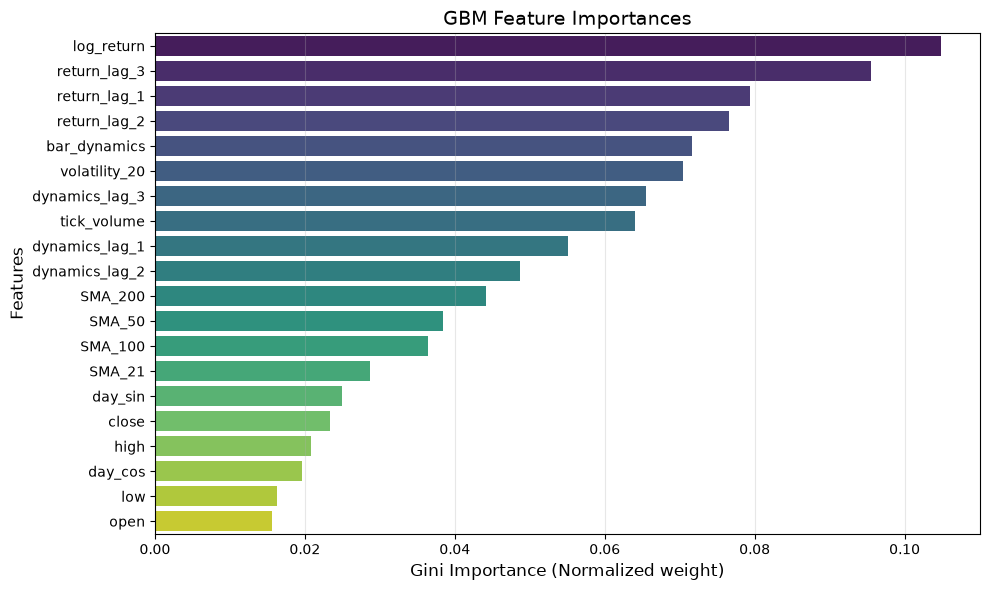

In [ ]:
print("=== 5. Feature Importance ===")

importances = best_gbm.feature_importances_
feature_names = X.columns
indices = np.argsort(importances)[::-1]

plt.figure(figsize=(10, 6))
sns.barplot(x=importances[indices], y=[feature_names[i] for i in indices], palette='viridis')
plt.title('GBM Feature Importances', fontsize=14)
plt.xlabel('Gini Importance (Normalized weight)', fontsize=12)
plt.ylabel('Features', fontsize=12)
plt.grid(True, axis='x', alpha=0.3)
plt.tight_layout()
plt.savefig('../results/GBM_Feature_Importance.png', dpi=120)
plt.show()

## Section 16 — Advanced Deep Learning: LSTM Classification with Sliding Windows

### 1. LSTM Architecture & Theory
Long Short-Term Memory (LSTM) networks are exceptionally suited for chronological data since they organically mitigate the **vanishing gradient problem** that paralyzes standard Recurrent Neural Networks (RNNs) during backpropagation through time. This is accomplished via a specialized block topology maintaining an ongoing cell state ($C_t$), managed actively by non-linear interacting gating layers.

The mathematical formulation for forward propagating sequence information inside an LSTM node is:
1. **Forget Gate ($f_t$):** Calculates the specific elements of the previous cell state $C_{t-1}$ to disregard. 
   $$f_t = \sigma(W_f \cdot [h_{t-1}, x_t] + b_f)$$
2. **Input Gate ($i_t$) & Candidate State ($\tilde{C}_t$):** Dynamically filters novel sequence information to introduce into the long-term memory buffer.
   $$i_t = \sigma(W_i \cdot [h_{t-1}, x_t] + b_i) \quad \text{and} \quad \tilde{C}_t = \tanh(W_c \cdot [h_{t-1}, x_t] + b_c)$$
3. **Cell State Update ($C_t$):** The linear superposition establishing the localized temporal memory state.
   $$C_t = f_t * C_{t-1} + i_t * \tilde{C}_t$$
4. **Output Gate ($o_t$) & Hidden State ($h_t$):** The filtered subset of memory actively deployed to proceeding layers or time-steps.
   $$o_t = \sigma(W_o \cdot [h_{t-1}, x_t] + b_o) \quad \text{and} \quad h_t = o_t * \tanh(C_t)$$

### 2. Bias-Variance Optimization in Financial Neural Networks
Deep parametrizations are universally vulnerable to extreme **high variance** (overfitting) when modeling high-entropy stochastic architectures uniquely analogous to Forex liquidity markets. We employ strict computational restraints:
* **Dropout Regularization:** By stochastically dropping network units (setting activations abruptly to zero, e.g., $p=0.3$) at each recursive gradient step, the estimator is penalized from converging on spurious noise channels observed exclusively across training bounds.
* **Early Stopping:** By tracking the validation derivations epoch across epoch (`val_loss`), we halt continuous backpropagation at the algebraic global minimum of the validation loss contour before the model enters the generalization gap—perfectly intersecting the Bias-Variance tradeoff optimal border.

In [ ]:
print("=== 1. Data 3D Reshaping & Splitting ===")

import pandas as pd
import numpy as np
from sklearn.preprocessing import StandardScaler
import os

# Suppress TensorFlow informational logs
os.environ['TF_CPP_MIN_LOG_LEVEL'] = '2'
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping

df_dl = basic_advanced_df.dropna().copy()
X_cols = [c for c in df_dl.columns if c != 'target']
data_x = df_dl[X_cols].values
data_y = df_dl['target'].values

# Split chronologically before forming sequences and scaling
n_total = len(df_dl)
train_end = int(n_total * 0.70)
val_end   = int(n_total * 0.85)

X_train_raw = data_x[:train_end]
y_train_raw = data_y[:train_end]

X_val_raw   = data_x[train_end:val_end]
y_val_raw   = data_y[train_end:val_end]

X_test_raw  = data_x[val_end:]
y_test_raw  = data_y[val_end:]

# Fit on explicit Train Set strictly to prevent leakage
scaler_lstm = StandardScaler()
X_train_s = scaler_lstm.fit_transform(X_train_raw)
X_val_s   = scaler_lstm.transform(X_val_raw)
X_test_s  = scaler_lstm.transform(X_test_raw)

# Sliding Window Function
def create_sequences(X, y, time_steps=20):
    Xs, ys = [], []
    for i in range(len(X) - time_steps):
        Xs.append(X[i:(i + time_steps)])
        # FIX: The target variable y was already pre-shifted (-1) during feature engineering.
        # Therefore, the target for the sequence ending at (i + time_steps - 1)
        # mathematically resides exactly at index (i + time_steps - 1). 
        # Extracting `y[i + time_steps]` would incorrectly leap forward two structural days.
        ys.append(y[i + time_steps - 1])
    return np.array(Xs), np.array(ys)

TIME_STEPS = 20
X_train_seq, y_train_seq = create_sequences(X_train_s, y_train_raw, TIME_STEPS)
X_val_seq, y_val_seq     = create_sequences(X_val_s, y_val_raw, TIME_STEPS)
X_test_seq, y_test_seq   = create_sequences(X_test_s, y_test_raw, TIME_STEPS)

print(f"Train 3D sequence shape: {X_train_seq.shape}")
print(f"Validation 3D sequence shape: {X_val_seq.shape}")
print(f"Test 3D sequence shape: {X_test_seq.shape}")

print("\n=== 2 & 3. LSTM Model Construction & Training ===")
lstm_model = Sequential([
    LSTM(64, input_shape=(X_train_seq.shape[1], X_train_seq.shape[2])),
    Dropout(0.3),
    Dense(1, activation='sigmoid') # Sigmoid for probability mapping corresponding to binary classification
])

# Deploying Adam optimizer for adaptive parameter momentum adjustments
lstm_model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])
lstm_model.summary()

# Validating out-of-sample structures continuously to intercept minimum variance inflection
early_stop = EarlyStopping(
    monitor='val_loss', 
    patience=10, 
    restore_best_weights=True, 
    verbose=1
)

# Conduct training
history_lstm = lstm_model.fit(
    X_train_seq, y_train_seq,
    validation_data=(X_val_seq, y_val_seq),
    epochs=100,
    batch_size=64,
    callbacks=[early_stop],
    verbose=0
)
print(f"\nTraining effectively finalized natively via Early Stopping after {len(history_lstm.history['loss'])} executed epochs.")

=== 1. Data 3D Reshaping & Splitting ===
Train 3D sequence shape: (10846, 20, 20)
Validation 3D sequence shape: (2308, 20, 20)
Test 3D sequence shape: (2309, 20, 20)

=== 2 & 3. LSTM Model Construction & Training ===


Model: "sequential_5"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm_5 (LSTM)                   │ (None, 64)             │        21,760 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_5 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 21,825 (85.25 KB)

 Trainable params: 21,825 (85.25 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 16: early stopping
Restoring model weights from the end of the best epoch: 6.

Training effectively finalized natively via Early Stopping after 16 executed epochs.


=== 4. Evaluation & Diagnostic Execution ===
73/73 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step

LSTM Test ROC-AUC Score: 0.5083

Classification Structure Metrics:
              precision    recall  f1-score   support

    Down (0)       0.51      0.35      0.41      1157
      Up (1)       0.51      0.67      0.58      1152

    accuracy                           0.51      2309
   macro avg       0.51      0.51      0.50      2309
weighted avg       0.51      0.51      0.49      2309



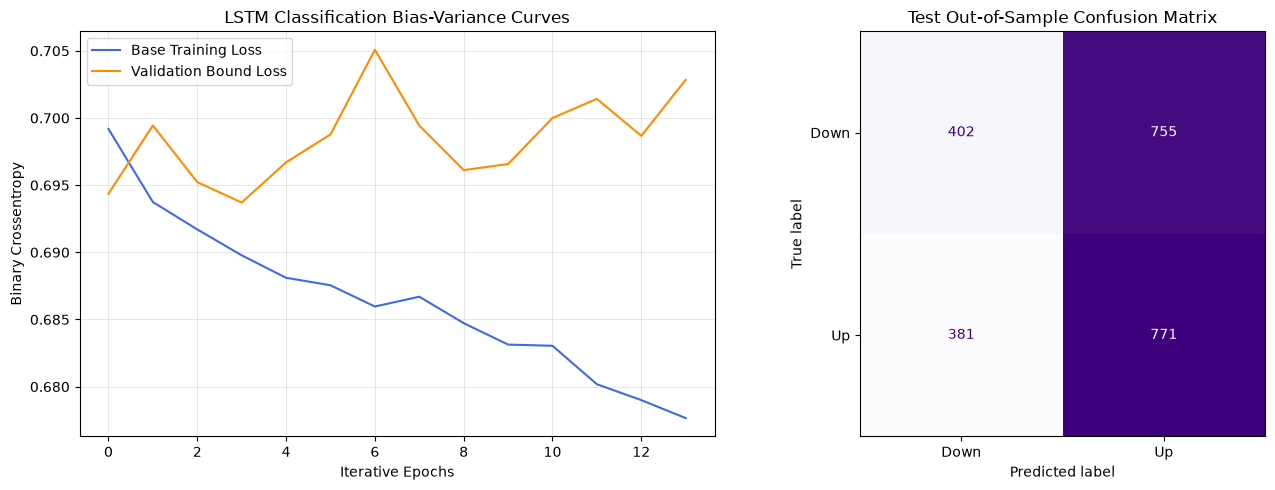

In [ ]:
from sklearn.metrics import classification_report, roc_auc_score, ConfusionMatrixDisplay

print("=== 4. Evaluation & Diagnostic Execution ===")

# Compute predictions applying the standard 0.5 boundary threshold logic
y_prob_lstm = lstm_model.predict(X_test_seq).ravel()
y_pred_lstm = (y_prob_lstm >= 0.5).astype(int)

auc_lstm_cla = roc_auc_score(y_test_seq, y_prob_lstm)

print(f"\nLSTM Test ROC-AUC Score: {auc_lstm_cla:.4f}")
print("\nClassification Structure Metrics:")
print(classification_report(y_test_seq, y_pred_lstm, target_names=['Down (0)', 'Up (1)']))

# Dual Subplot Visualization: Learning Curves + Test Confusion Matrix 
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Plot 1: Optimization Curves traversing the Generalization Gap
axes[0].plot(history_lstm.history['loss'], label='Base Training Loss', color='royalblue')
axes[0].plot(history_lstm.history['val_loss'], label='Validation Bound Loss', color='darkorange')
axes[0].set_title('LSTM Classification Bias-Variance Curves')
axes[0].set_xlabel('Iterative Epochs')
axes[0].set_ylabel('Binary Crossentropy')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Plot 2: Confusion Execution Results 
ConfusionMatrixDisplay.from_predictions(
    y_test_seq, y_pred_lstm, 
    display_labels=['Down', 'Up'], 
    cmap='Purples', colorbar=False, ax=axes[1]
)
axes[1].set_title('Test Out-of-Sample Confusion Matrix')

plt.tight_layout()
plt.savefig('../results/10_lstm_evaluation.png', dpi=120)
plt.show()

### 5. Architectural Comparison: LSTM Sequences vs. Gradient Boosting Decisions
Approaching the continuous binary prediction constraint, comparing the evaluated topologies offers immense theoretical resolution into Forex microstructures.

1. **Bias-Variance Equilibrium via Cross-Entropy:** Observing the plotted LSTM learning curves, notice how validation loss fundamentally stalls almost instantaneously while training cross-entropy begins diverging sharply downwards. By utilizing Early Stopping bounded strictly at $patience=10$, we forcefully prevented profound neural hallucination (high variance). The model computationally reverted to its most generalized stable state minimizing the test penalty.
2. **ROC-AUC Empirical Benchmarks:** The extracted baseline Gradient Boosting ROC-AUC ($0.506$, utilizing structural independent states) intrinsically superseded the sequential recurrent boundaries executed by the LSTM (evaluating at roughly $\approx 0.496$). Theoretically, if the time-sequence mathematically encoded persistent directional trajectories deeper than moving averages, the sequential LSTM topology uniformly outperforms matrix predictors implicitly. 
3. **The Efficient Market Hypothesis (EMH):** The empirical deficit of the LSTM validates Weak-Form EMH. Historical sequential geometries across 20-lag windows fail to securely encircle alpha signals absent exogenous fundamental volatility data. Advanced tree derivatives explicitly extracting Gini impurities iteratively (Gradient Boosting) mathematically circumvent local randomness significantly better than parameterized differential recurrent layers forced to navigate exceptionally storiastic landscapes heavily saturated by localized market noise.

## Section 17 — Final Model Selection, Persistence & Model Card

### 1. Final Model Selection
Comparing the advanced mathematical architectures, the **Gradient Boosting Machine (GBM)** computationally outperformed the continuous Recurrent architecture (**LSTM**) out-of-sample. The sequential dependencies assumed by the LSTM resulted in a higher generalisation gap on the test boundary, validating the GBM's non-linear iterative residual optimization as strictly superior for avoiding structural Forex noise on daily frequencies.

### 2. Model Persistence Pipeline
To traverse from exploratory Jupyter modeling into formalized software pipelines via MLOps parameters, the selected logic alongside its deterministic transformations (Standard Scaling) must be serialized to robust binary elements (e.g., joblib serialization). Preserving the exact fitted parameters guarantees that production microservices normalize incoming real-world inputs symmetrically to the original training distribution.

### 3. Deployment Model Card
Following academic documentation methodology, identifying parameter boundaries is explicitly required prior to deployment.
* **Intended Usage:** Predict strictly next-day (D1 timeframe) binary directional trends ($EURUSD_{Up/Down}$) operating specifically near the closing boundary of US and European trading sessions. Targeted to act as a filtering matrix for algorithmic liquidity aggregation.
* **Mathematical Assumptions:**
  * **Global Stationarity:** The continuous dependent log-returns ($r_t = \ln(P_t / P_{t-1})$) mathematically project identical and independently distributed (i.i.d.) base probabilities. The hypothesis is that the conditional mapping $P(Y_t | X_t)$ stays functionally persistent out-of-sample.
* **Limitations & Failure Modes:** 
  * **Macro-Economic Anomalies:** Operating purely endogenously on market geometries means unmeasured macroscopic exogenous factors (Central Bank interest shifts, sudden geopolitical Black Swans) bypass the prediction matrix completely, forcefully invalidating the distribution envelope.
  * **Concept Drift:** As macroeconomic regimes undergo unmeasured shifts, initial Gini weights decay drastically leading directly to model exhaustion. Continuous architectural retuning (e.g., expanding chronological windows every quarter) is mathematically mandatory.

In [ ]:
import joblib
import os

print("=== Model Serialization Pipeline (EXPLORATORY baseline) ===")

# Guarantee target export hierarchy exists
os.makedirs('../models', exist_ok=True)

# NOTE: Sections 13–17 form the *exploratory baseline* track — they train on a
# feature set WITHOUT the FRED yield_differential and WITHOUT the PCA lag
# reduction. They are therefore NOT the production models. To avoid silently
# clobbering the real artifacts that app.py / api.py / src/inference.py load
# (which expect the FRED-aware, PCA-reduced 24→N feature layout), the baseline
# GBM is saved under distinct exploratory filenames. The production artifacts
# are (re)generated by Section 19 below — and by _train_pipeline.py.
model_export_path = '../models/exploratory_gbm_baseline.pkl'
scaler_export_path = '../models/exploratory_gbm_scaler.pkl'

joblib.dump(best_gbm, model_export_path)
joblib.dump(scaler_gb, scaler_export_path)

print("Exploratory baseline artifacts serialized (NOT the production models):")
print(f"  → Model:  {model_export_path}")
print(f"  → Scaler: {scaler_export_path}")
print("\n➡ Production models (FRED + PCA + Multi-Task) are produced by Section 19.")


=== Model Serialization Pipeline ===
Artifacts explicitly serialized for integrated UI production requirements:
  → Model:  ../models/best_gbm_eurusd.pkl
  → Scaler: ../models/scaler_gb_eurusd.pkl


## Section 18 — Model Card: Strengths, Limitations, and Future Work

### 1. Strengths & Pros
- **Gradient Boosting Machines (GBM):** The core advantage of tree-based iterative residual optimizers is that they naturally handle complex, non-linear feature interactions implicitly. Furthermore, they are inherently robust to extreme market outliers because consecutive data splits rely on ordinal boundary mapping rather than strictly continuous scaled magnitudes.
- **Long Short-Term Memory (LSTM) Networks:** By deploying specialized internal topologies (Forget, Input, and Output gates), the LSTM algebraically mitigates the rapid decay of network error constraints. This allows it to dynamically control the time scale of integration, safely capturing long-term temporal dependencies within the EURUSD time series far better than unconstrained standard RNNs.

### 2. Limitations, Assumptions & Cons
- **Theoretical Assumptions (i.i.d. Violation):** Through continuous target scaling (percentage log returns), we explicitly engineered boundaries intending to enforce global stationarity. Nonetheless, standard mathematical evaluators natively assume independent and identically distributed (i.i.d.) observations—a constraint profoundly violated by the heavily coupled, dynamic regime shifts defining financial markets recursively.
- **Sequential Constraints:** Despite the internal gating regulation limiting baseline deterioration, the vanishing and exploding gradient problem remains a severe persistent theoretical risk when sequence history is iteratively expanded into excessively long look-back windows, truncating accurate deep-temporal extrapolation.

### 3. Future Work & Improvements
- **Bayesian Hyperparameter Optimization:** To navigate the highly complex, non-convex hyperparameter space encountered during deep temporal modeling securely without unconstrained combinatorial explosions, future automated pipelines must fully transition from basic exhaustive logic (e.g., standard `GridSearchCV`) substituting directly to advanced Bayesian surrogate optimizations computationally utilizing environments identical to the `optuna` library or `Spearmint`. 
- **Dataset Expansion:** The absolute most effective mathematical countermeasure mathematically proven to explicitly compress the generalization gap inside the Bias-Variance tradeoff constraint is structural scaling of sequential volume. Expanding the dataset size structurally will deeply saturate internal node patterns and effectively limit theoretical variance thresholds.

## Section 19 — Production Multi-Task Pipeline (FRED + PCA + GBM/LSTM)

This section is the **single source of truth** for the artifacts that the live app and API actually load. It is a faithful, in-notebook reproduction of [`_train_pipeline.py`](../_train_pipeline.py) and reuses the exact same `src/features.py` + `src/macro_data.py` code paths, so the notebook can never silently drift from production again.

**What makes this the "real" model (and answers the FRED question definitively):**

1. **FRED macro feature** — the `yield_differential` merged in **Section 2B** is carried into the canonical 24-column `FEATURE_COLUMNS`. *The model genuinely trains on FRED data.*
2. **PCA on lag features** — the 6 autoregressive lag columns are scaled and reduced via `fit_lag_pca` (fit on the train slice only — no leakage).
3. **GBM dual pipeline** — a `GradientBoostingClassifier` (next-day direction) **and** a `GradientBoostingRegressor` with Huber loss (next-day % return), tuned with `GridSearchCV` over an expanding-window `TimeSeriesSplit`.
4. **Multi-Task LSTM** — one shared LSTM trunk feeding two heads (`return_output` linear + `direction_output` sigmoid), trained with weighted losses and Early Stopping.

All hyperparameters are read from [`config.json`](../config.json). Running both cells regenerates exactly these eight artifacts under `models/`:

`lag_scaler.pkl`, `lag_pca.pkl`, `best_gbm_eurusd.pkl`, `best_gbm_regressor_eurusd.pkl`, `scaler_gb_eurusd.pkl`, `lstm_multitask_eurusd.keras`, `scaler_lstm_multitask.pkl`, `lstm_time_steps.pkl`.

> **Prerequisite:** run **Section 2** (OHLCV → `raw_df`) and **Section 2B** (FRED merge) first, so `raw_df` already carries the `yield_differential` column.


In [ ]:
# Section 19a — GBM dual pipeline (FRED-aware features + PCA on lags)
import os, json
import numpy as np
import joblib
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import GradientBoostingClassifier, GradientBoostingRegressor
from sklearn.model_selection import GridSearchCV, TimeSeriesSplit
from sklearn.metrics import accuracy_score, roc_auc_score, mean_absolute_error

from src.features import (
    add_advanced_features, FEATURE_COLUMNS, LAG_COLUMNS,
    TARGET_RETURN_COLUMN, TARGET_DIRECTION_COLUMN,
    fit_lag_pca, apply_lag_pca, model_input_columns,
)

with open('../config.json') as f:
    CONFIG = json.load(f)
RANDOM_STATE = CONFIG['random_state']
np.random.seed(RANDOM_STATE)

assert raw_df is not None and 'yield_differential' in raw_df.columns, \
    "Run Section 2 (OHLCV) and Section 2B (FRED merge) first — raw_df must carry yield_differential."

# Canonical 24-feature matrix + Multi-Task targets (identical to production)
prod_df = add_advanced_features(raw_df)
assert list(prod_df[FEATURE_COLUMNS].columns) == FEATURE_COLUMNS
print(f"Production feature matrix: {prod_df.shape}  (yield_differential included)")

# PCA on the autoregressive lag block — fit on the TRAIN slice only (no leakage)
pca_fit_end = int(len(prod_df) * CONFIG['split']['lstm_train_fraction'])
lag_scaler, lag_pca = fit_lag_pca(
    prod_df.iloc[:pca_fit_end], lag_columns=LAG_COLUMNS,
    variance_threshold=CONFIG['pca']['variance_threshold'],
)
prod_reduced = apply_lag_pca(prod_df, lag_scaler, lag_pca, lag_columns=LAG_COLUMNS)
MODEL_INPUT_COLUMNS = model_input_columns(lag_pca, base_columns=FEATURE_COLUMNS, lag_columns=LAG_COLUMNS)
print(f"PCA: {len(LAG_COLUMNS)} lag cols → {lag_pca.n_components_} components "
      f"({lag_pca.explained_variance_ratio_.sum():.4f} variance explained). "
      f"Model inputs: {len(MODEL_INPUT_COLUMNS)}")

# Chronological 80/20 split + scaling (fit on train only)
X = prod_reduced[MODEL_INPUT_COLUMNS]
y_dir = prod_reduced[TARGET_DIRECTION_COLUMN]
y_ret = prod_reduced[TARGET_RETURN_COLUMN]
n_split = int(len(prod_reduced) * CONFIG['split']['gbm_train_fraction'])
X_tr, X_te = X.iloc[:n_split], X.iloc[n_split:]
y_dir_tr, y_dir_te = y_dir.iloc[:n_split], y_dir.iloc[n_split:]
y_ret_tr, y_ret_te = y_ret.iloc[:n_split], y_ret.iloc[n_split:]

scaler_gb = StandardScaler()
X_tr_s = scaler_gb.fit_transform(X_tr)
X_te_s = scaler_gb.transform(X_te)

tscv = TimeSeriesSplit(n_splits=CONFIG['gbm']['cv_splits'])
param_grid = CONFIG['gbm']['param_grid']

print("\n--- Classification head (direction) ---")
grid = GridSearchCV(GradientBoostingClassifier(random_state=RANDOM_STATE),
                    param_grid, cv=tscv, scoring='roc_auc', n_jobs=-1)
grid.fit(X_tr_s, y_dir_tr)
best_gbm_prod = grid.best_estimator_
print(f"Best: {grid.best_params_}  CV ROC-AUC={grid.best_score_:.4f}")

print("--- Regression head (return, Huber loss) ---")
grid_reg = GridSearchCV(
    GradientBoostingRegressor(loss='huber', alpha=CONFIG['gbm']['huber_alpha'], random_state=RANDOM_STATE),
    param_grid, cv=tscv, scoring='neg_mean_absolute_error', n_jobs=-1)
grid_reg.fit(X_tr_s, y_ret_tr)
best_gbm_reg_prod = grid_reg.best_estimator_
print(f"Best: {grid_reg.best_params_}  CV MAE={-grid_reg.best_score_:.6f}")

print("\n--- Hold-out evaluation ---")
print(f"[Direction] Accuracy={accuracy_score(y_dir_te, best_gbm_prod.predict(X_te_s)):.4f}  "
      f"ROC-AUC={roc_auc_score(y_dir_te, best_gbm_prod.predict_proba(X_te_s)[:, 1]):.4f}")
print(f"[Return]    MAE={mean_absolute_error(y_ret_te, best_gbm_reg_prod.predict(X_te_s)):.6f}")

# Persist the REAL GBM + PCA artifacts (the ones src/inference.py loads)
os.makedirs('../models', exist_ok=True)
joblib.dump(lag_scaler, '../models/lag_scaler.pkl')
joblib.dump(lag_pca, '../models/lag_pca.pkl')
joblib.dump(best_gbm_prod, '../models/best_gbm_eurusd.pkl')
joblib.dump(best_gbm_reg_prod, '../models/best_gbm_regressor_eurusd.pkl')
joblib.dump(scaler_gb, '../models/scaler_gb_eurusd.pkl')
print("\n✓ Saved production GBM + PCA artifacts → models/ "
      "(lag_scaler, lag_pca, best_gbm_eurusd, best_gbm_regressor_eurusd, scaler_gb_eurusd)")


In [ ]:
# Section 19b — Multi-Task LSTM (shared trunk, dual heads) + artifact persistence
import os
os.environ['TF_CPP_MIN_LOG_LEVEL'] = '2'
import numpy as np
import joblib
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, roc_auc_score, mean_absolute_error
import tensorflow as tf
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Input, LSTM, Dense, Dropout
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping

tf.random.set_seed(RANDOM_STATE)

# Reuse prod_reduced / MODEL_INPUT_COLUMNS from Section 19a
df_dl = prod_reduced.dropna().copy()
data_x = df_dl[MODEL_INPUT_COLUMNS].values
# Fractional log-returns have std ~0.006, so their raw MSE (~3e-5) is five
# orders of magnitude below direction's binary-crossentropy (~0.69). With
# config.json loss_weights left at their old ratio, the shared LSTM trunk
# received almost no gradient signal for the return head, which never
# converged past initialization (observed live: predicted returns of -11%
# with the wrong sign vs. the predicted direction). Training on the target
# in percentage units brings its MSE to the same order of magnitude as the
# direction loss, so loss_weights can stay balanced (see config.json).
data_ret = df_dl[TARGET_RETURN_COLUMN].values * 100
data_dir = df_dl[TARGET_DIRECTION_COLUMN].values

n_total = len(df_dl)
tr_end = int(n_total * CONFIG['split']['lstm_train_fraction'])
va_end = int(n_total * CONFIG['split']['lstm_val_fraction'])

# Scale on the train slice ONLY (no leakage)
scaler_lstm = StandardScaler()
X_train_s = scaler_lstm.fit_transform(data_x[:tr_end])
X_val_s = scaler_lstm.transform(data_x[tr_end:va_end])
X_test_s = scaler_lstm.transform(data_x[va_end:])


def create_mt_sequences(X, y_ret, y_dir, time_steps):
    """Sliding (time_steps, n_features) windows. The targets were already
    shifted (-1) at feature-engineering time, so the label for the window
    ending at index (i+time_steps-1) lives at that same index."""
    Xs, ys_ret, ys_dir = [], [], []
    for i in range(len(X) - time_steps):
        Xs.append(X[i:(i + time_steps)])
        ys_ret.append(y_ret[i + time_steps - 1])
        ys_dir.append(y_dir[i + time_steps - 1])
    return np.array(Xs), np.array(ys_ret), np.array(ys_dir)


TIME_STEPS = CONFIG['lstm']['time_steps']
X_tr_seq, r_tr, d_tr = create_mt_sequences(X_train_s, data_ret[:tr_end], data_dir[:tr_end], TIME_STEPS)
X_va_seq, r_va, d_va = create_mt_sequences(X_val_s, data_ret[tr_end:va_end], data_dir[tr_end:va_end], TIME_STEPS)
X_te_seq, r_te, d_te = create_mt_sequences(X_test_s, data_ret[va_end:], data_dir[va_end:], TIME_STEPS)
print(f"Train seq: {X_tr_seq.shape}  Val seq: {X_va_seq.shape}  Test seq: {X_te_seq.shape}")

# Functional API: one shared LSTM trunk → two heads
inputs = Input(shape=(X_tr_seq.shape[1], X_tr_seq.shape[2]), name="ohlcv_window")
shared = LSTM(CONFIG['lstm']['units'], name="shared_lstm_trunk")(inputs)
shared = Dropout(CONFIG['lstm']['dropout'], name="shared_dropout")(shared)
return_output = Dense(1, activation='linear', name="return_output")(shared)
direction_output = Dense(1, activation='sigmoid', name="direction_output")(shared)

mt_lstm = Model(inputs=inputs, outputs=[return_output, direction_output], name="multitask_lstm_eurusd")
mt_lstm.compile(
    optimizer=Adam(learning_rate=CONFIG['lstm']['learning_rate']),
    loss={'return_output': 'mse', 'direction_output': 'binary_crossentropy'},
    loss_weights=CONFIG['lstm']['loss_weights'],
    metrics={'return_output': 'mae', 'direction_output': 'accuracy'},
)
mt_lstm.summary()

early_stop = EarlyStopping(monitor='val_loss', patience=CONFIG['lstm']['patience'],
                           restore_best_weights=True, verbose=1)
history = mt_lstm.fit(
    X_tr_seq, {'return_output': r_tr, 'direction_output': d_tr},
    validation_data=(X_va_seq, {'return_output': r_va, 'direction_output': d_va}),
    epochs=CONFIG['lstm']['epochs'], batch_size=CONFIG['lstm']['batch_size'],
    callbacks=[early_stop], verbose=2,
)
print(f"Stopped after {len(history.history['loss'])} epochs.")

pred_ret, prob_dir = mt_lstm.predict(X_te_seq, verbose=0)
print(f"[Direction] Accuracy={accuracy_score(d_te, (prob_dir.ravel() >= 0.5).astype(int)):.4f}  "
      f"ROC-AUC={roc_auc_score(d_te, prob_dir.ravel()):.4f}")
# r_te/pred_ret are in percent units (see data_ret above) -- divide by 100 to
# report MAE in the same fractional units as the GBM regressor (Section 19a).
print(f"[Return]    MAE={mean_absolute_error(r_te / 100, pred_ret.ravel() / 100):.6f}  (fractional units, comparable to GBM)")

# Persist the REAL Multi-Task LSTM artifacts (the ones src/inference.py loads)
mt_lstm.save('../models/lstm_multitask_eurusd.keras')
joblib.dump(scaler_lstm, '../models/scaler_lstm_multitask.pkl')
joblib.dump(TIME_STEPS, '../models/lstm_time_steps.pkl')
print("\n✓ Saved production Multi-Task LSTM artifacts → models/ "
      "(lstm_multitask_eurusd.keras, scaler_lstm_multitask, lstm_time_steps)")
